# Лабораторная работа №1. Освоение базового ML-пайплайна на табличных данных

## Введение

В данной лабораторной работе проводится полный цикл машинного обучения на примере датасета о студентах, содержащего информацию об их успеваемости (CGPA), режиме сна, времени учебы, использовании социальных сетей, физической активности и уровне стресса

**Цель работы:**
- Освоить базовый ML-пайплайн на табличных данных
- Провести разведочный анализ данных (EDA) с визуализацией
- Выполнить предобработку данных: обработку пропусков, выбросов, кодирование категориальных признаков
- Провести feature engineering и отбор признаков
- Обучить модели машинного обучения:
  - Linear Regression для прогнозирования успеваемости студентов (CGPA)
  - Logistic Regression для классификации риска развития депрессии
- Оценить качество моделей и проанализировать результаты

## EDA

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import pandas as pd


df = pd.read_csv("/content/drive/MyDrive/student_lifestyle_100k.csv")
df.head(10)

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False
5,1006,22,Female,Medical,3.31,6.5,3.5,4.1,129,2,False
6,1007,18,Male,Science,2.14,4.4,4.0,3.1,73,8,True
7,1008,18,Male,Engineering,3.27,7.0,3.4,7.6,68,4,False
8,1009,21,Male,Business,2.71,4.8,8.6,0.3,82,5,False
9,1010,24,Male,Engineering,3.36,5.7,1.5,3.7,59,3,False


In [ ]:
df.info()

df['Age'] = df['Age'].astype('int8')
df['Stress_Level'] = df['Stress_Level'].astype('int8')
df['CGPA'] = df['CGPA'].astype('float32')
df['Sleep_Duration'] = df['Sleep_Duration'].astype('float32')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


### Удаление лишних колонок

In [ ]:
df.drop(columns=["Student_ID"], inplace=True)
df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


### Проверка на дубли и NaN

In [ ]:
df_duplicated = df[df.duplicated()]
df_have_nan = df.isna().any().any()

print(f"Всего дублей: {df_duplicated.shape}")
print(f"Есть ли NaN: {df_have_nan}")

Всего дублей: (0, 10)
Есть ли NaN: False


Найдено числовых признаков: 7


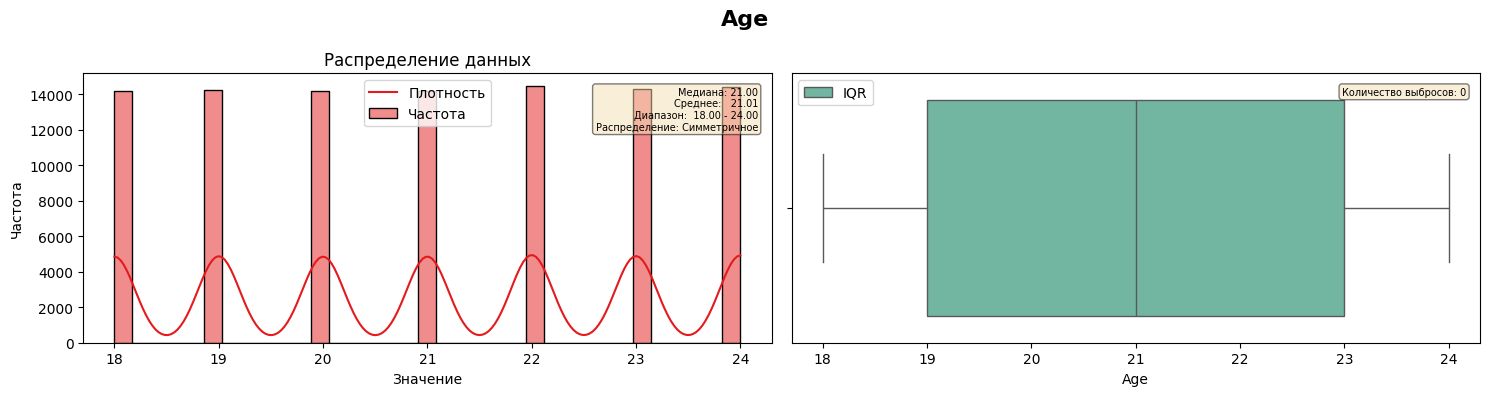

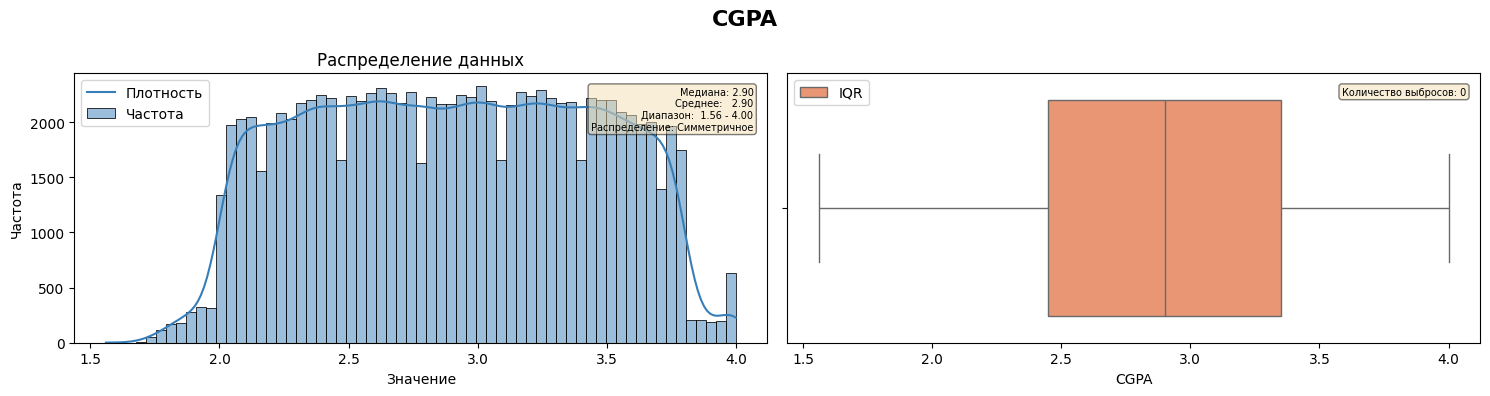

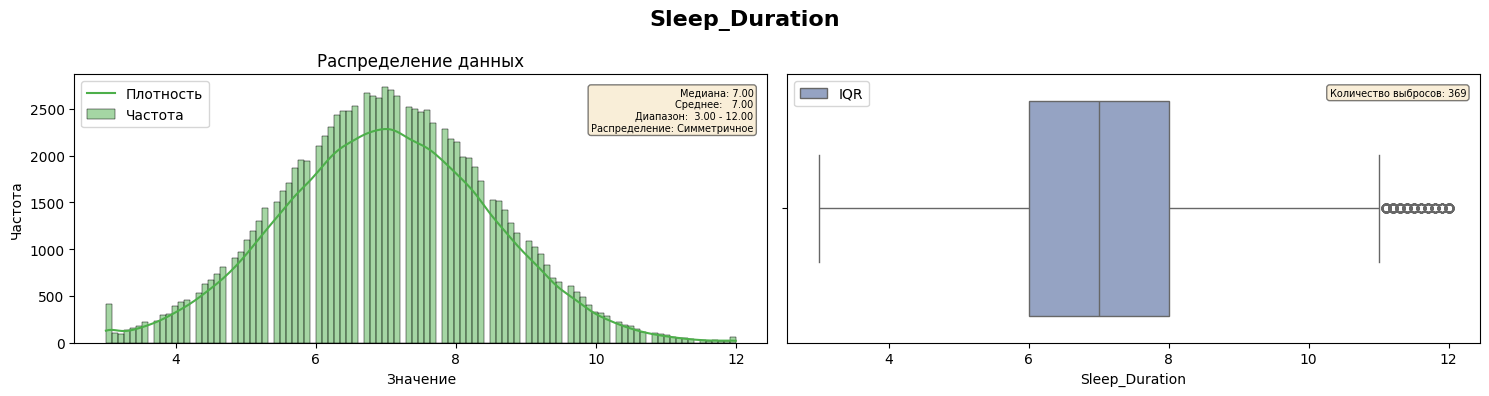

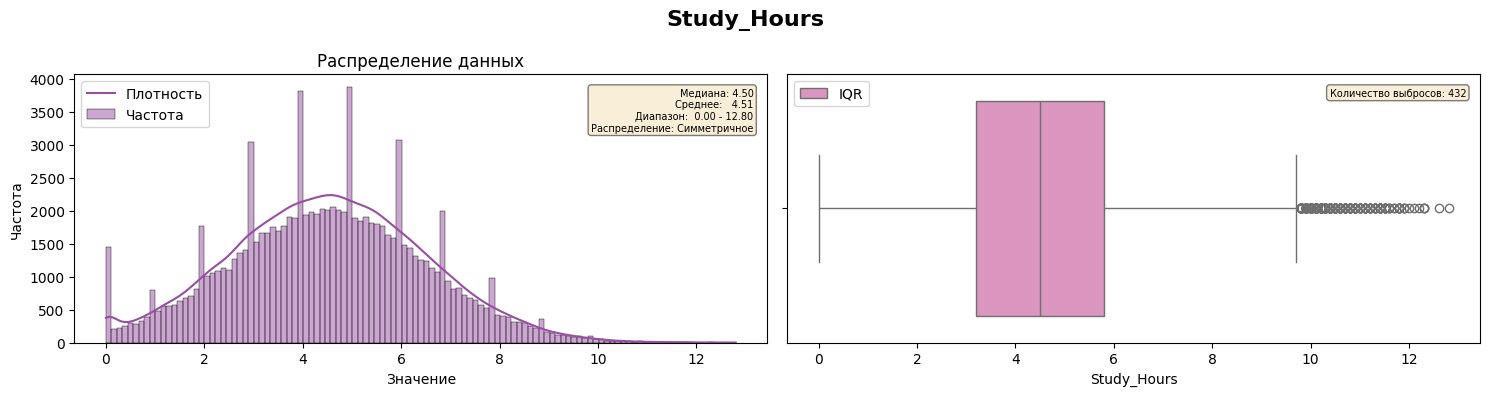

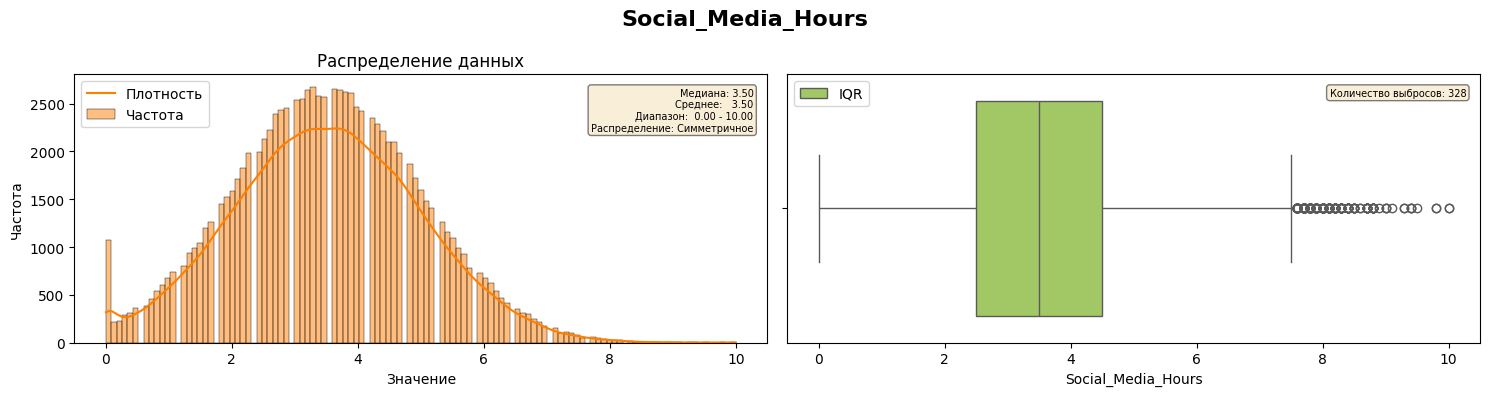

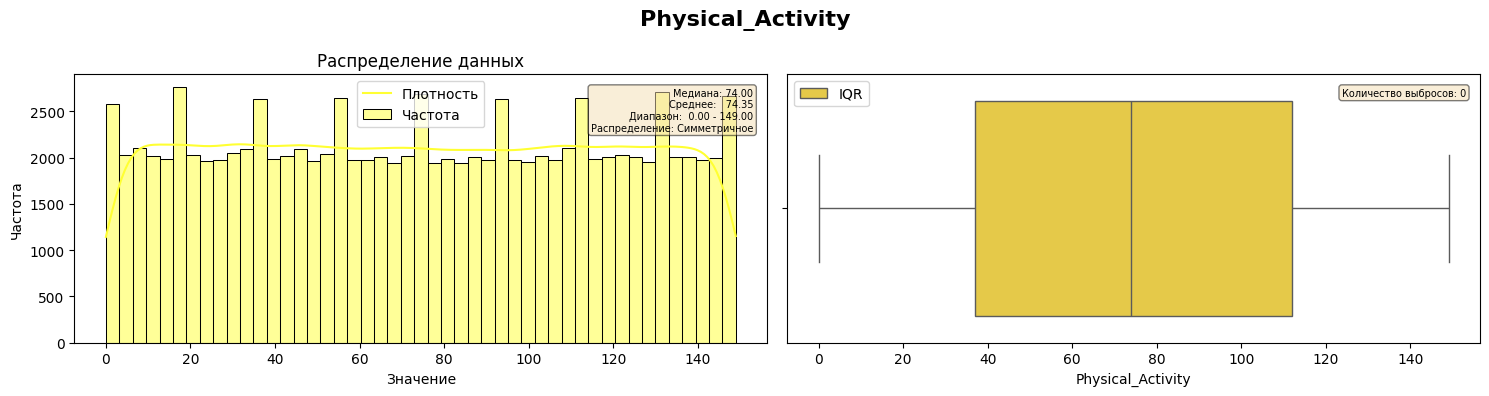

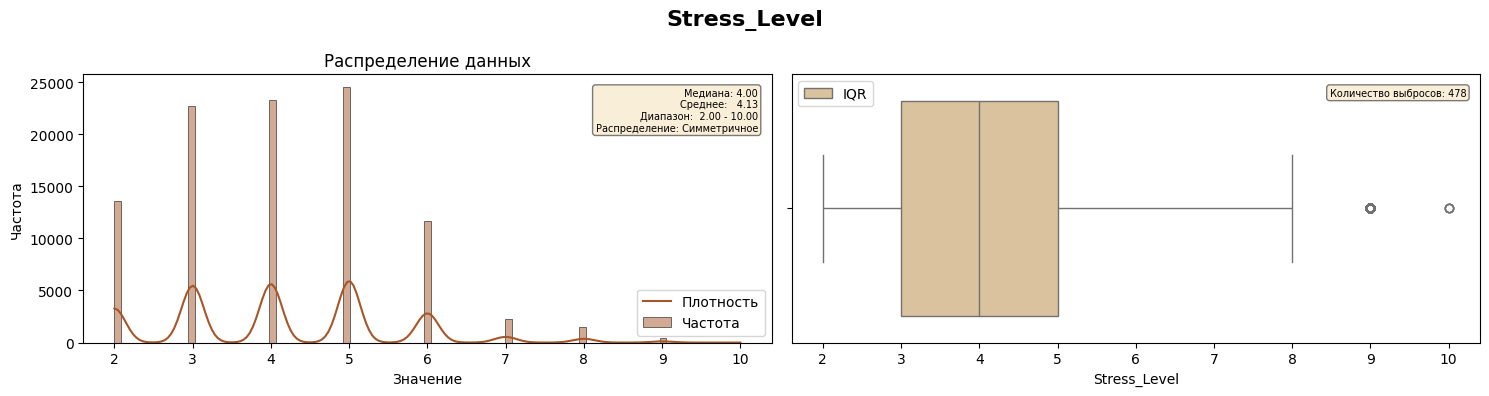

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

number_columns = df.select_dtypes(include="number").columns.tolist()

color_palette_1 = sns.color_palette("Set1", len(number_columns))
color_palette_2 = sns.color_palette("Set2", len(number_columns))

print(f"Найдено числовых признаков: {len(number_columns)}")

for index, column in enumerate(number_columns):
  fig, axes = plt.subplots(1, 2, figsize=(15, 4))

  sns.histplot(data=df, x=column, ax=axes[0], kde=True, color=color_palette_1[index])

  axes[0].set_title("Распределение данных")
  axes[0].set_xlabel("Значение")
  axes[0].set_ylabel("Частота")
  axes[0].legend(["Плотность", "Частота"], loc='best')

  skew = df[column].skew()

  if abs(skew) < 0.5:
    skew_text = "Симметричное"
  elif skew > 0:
    skew_text = "Ассимитричное сроава"
  else:
    skew_text = "Ассимитричное слева"

  stats_text = (f"Медиана: {df[column].median():.2f}\n"
  f"Среднее:   {df[column].mean():.2f}\n"
  f"Диапазон:  {df[column].min():.2f} - {df[column].max():.2f}\n"
  f"Распределение: {skew_text}"
  )

  axes[0].text(0.98, 0.95, stats_text, transform=axes[0].transAxes,
              fontsize=7, verticalalignment='top', horizontalalignment='right',
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

  sns.boxplot(data=df, x=column, ax=axes[1], color=color_palette_2[index])

  axes[1].legend(["IQR"], loc='best')

  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
  outliers_text = (f"Количество выбросов: {outliers_count}")

  axes[1].text(0.98, 0.95, outliers_text, transform=axes[1].transAxes,
               fontsize=7, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

  plt.suptitle(f'{column}', fontsize=16, fontweight='bold')
  plt.tight_layout()
  plt.show()




Распределение числовых признаков нормальное, симметричное. Количество выбросов не катострофически большое

### Проверка корреляции признаков

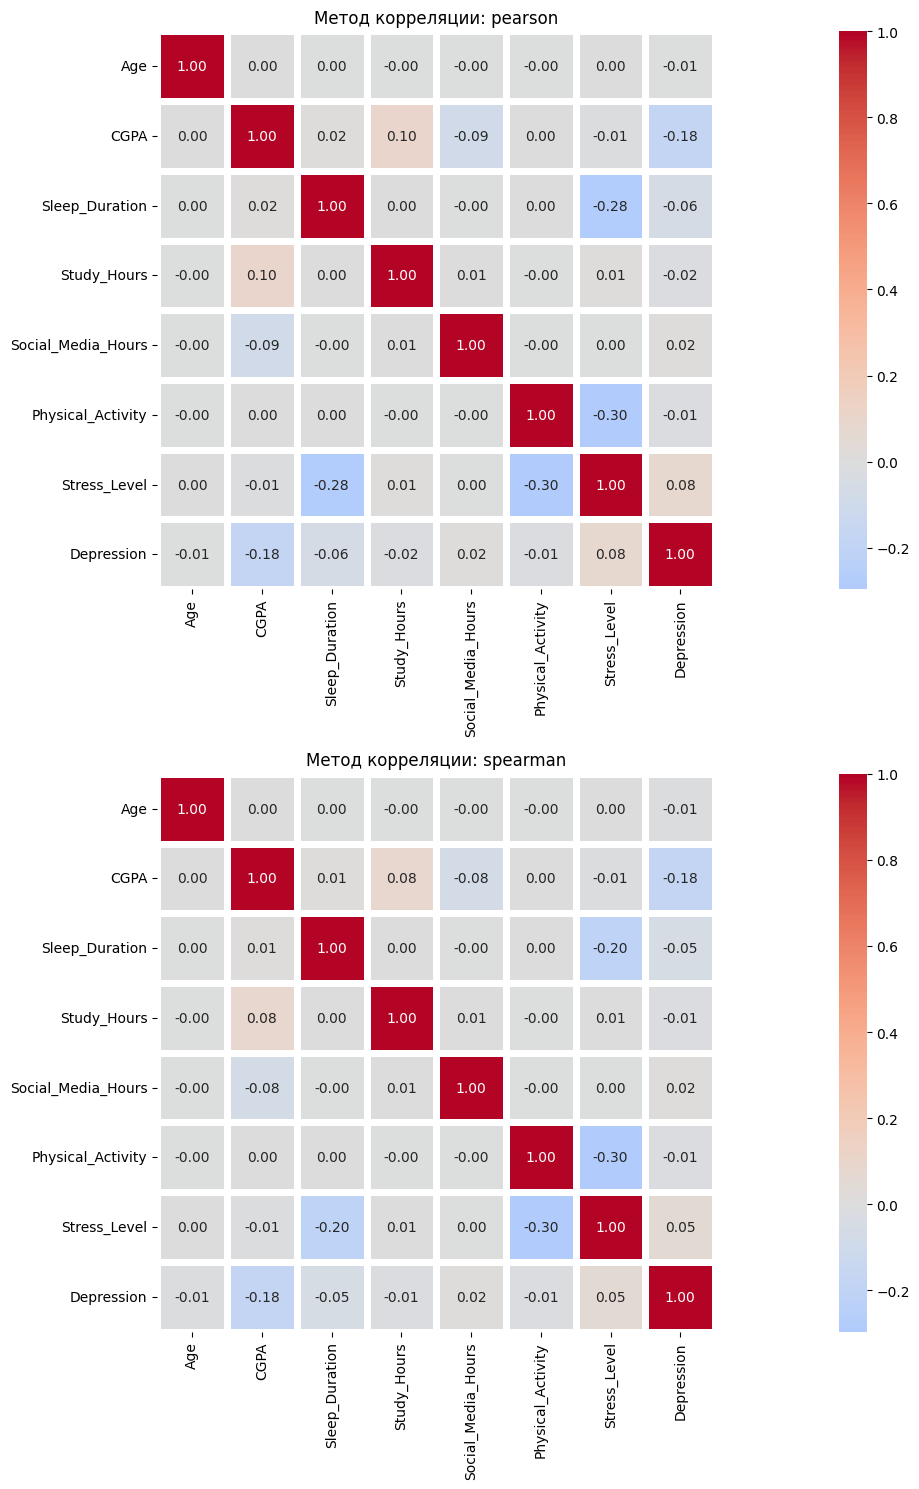

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(25, 15))

df["Depression"] = df["Depression"].astype(int)

number_columns = df.select_dtypes(include="number").columns.tolist()

for i, cur_method in enumerate(['pearson', 'spearman']):
  corr = df[number_columns].corr(method=cur_method)
  sns.heatmap(
      data=corr,
      annot=True,
      linewidths=5,
      center=0,
      square=True,
      fmt='.2f',
      cmap='coolwarm',
      ax=axes[i]

  )
  axes[i].set_title(f"Метод корреляции: {cur_method}")
plt.tight_layout()
plt.show()


Из корреляции можем сделать следующие выводы:
- Возраст почти не коррелирует ни с какими признаками. Можем смело удалять
- Средний балл кореллирует с депрессией, временем учебы и временем, проведенных в соц. сетях
- Депрессия кореллирует со средним баллом, продолжительностью сна и уровнем стресса
- С остальными признаками целевые переменные коррелируют слабо. Осмелюсь сделать прогноз, что получить хорошие метрики будет тяжело

/tmp/ipykernel_11094/1889118191.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_dep.index, y=gender_dep.values, ax=axes[0], palette='Set2')
/tmp/ipykernel_11094/1889118191.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_dep.index, y=dept_dep.values, ax=axes[1], palette='Set3')


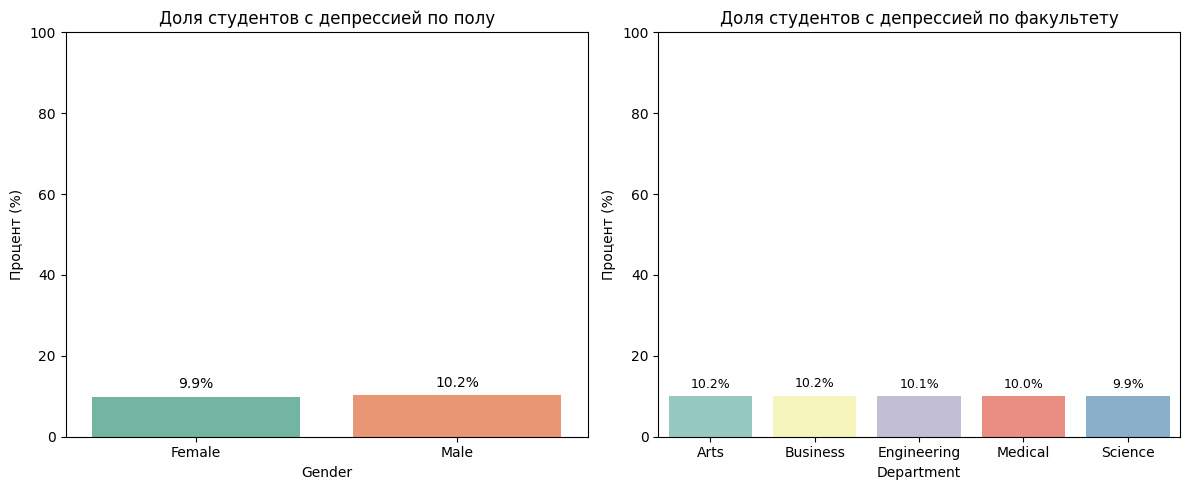

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_dep = df.groupby('Gender')['Depression'].mean() * 100
sns.barplot(x=gender_dep.index, y=gender_dep.values, ax=axes[0], palette='Set2')
axes[0].set_title('Доля студентов с депрессией по полу', fontsize=12)
axes[0].set_ylabel('Процент (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(gender_dep.values):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=10)

dept_dep = df.groupby('Department')['Depression'].mean() * 100
sns.barplot(x=dept_dep.index, y=dept_dep.values, ax=axes[1], palette='Set3')
axes[1].set_title('Доля студентов с депрессией по факультету', fontsize=12)
axes[1].set_ylabel('Процент (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(dept_dep.values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_11094/3563701140.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='CGPA', ax=axes[0], palette='Set2')
/tmp/ipykernel_11094/3563701140.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='CGPA', ax=axes[1], palette='Set3')
/tmp/ipykernel_11094/3563701140.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


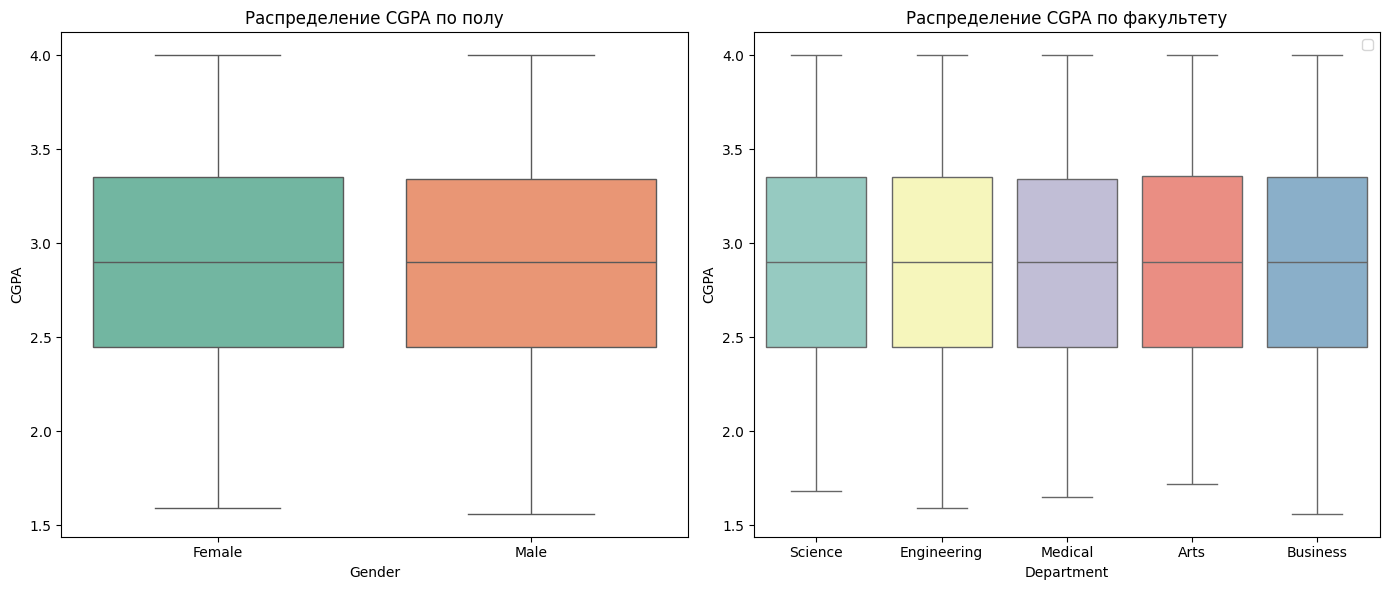

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='Gender', y='CGPA', ax=axes[0], palette='Set2')
gender_means = df.groupby('Gender')['CGPA'].mean().reset_index()
axes[0].set_title('Распределение CGPA по полу', fontsize=12)

sns.boxplot(data=df, x='Department', y='CGPA', ax=axes[1], palette='Set3')

axes[1].set_title('Распределение CGPA по факультету', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

Из вышепредставленных графиков можно сделать вывод, что факультет и пол также не влияют не на один из наших предсказываемых параметров. Можем удалять

### Удаление ненужных колонок

In [ ]:
df.drop(columns=['Age', 'Gender', 'Department'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CGPA                100000 non-null  float32
 1   Sleep_Duration      100000 non-null  float32
 2   Study_Hours         100000 non-null  float64
 3   Social_Media_Hours  100000 non-null  float64
 4   Physical_Activity   100000 non-null  int64  
 5   Stress_Level        100000 non-null  int8   
 6   Depression          100000 non-null  int64  
dtypes: float32(2), float64(2), int64(2), int8(1)
memory usage: 3.9 MB


### Удаление выбросов

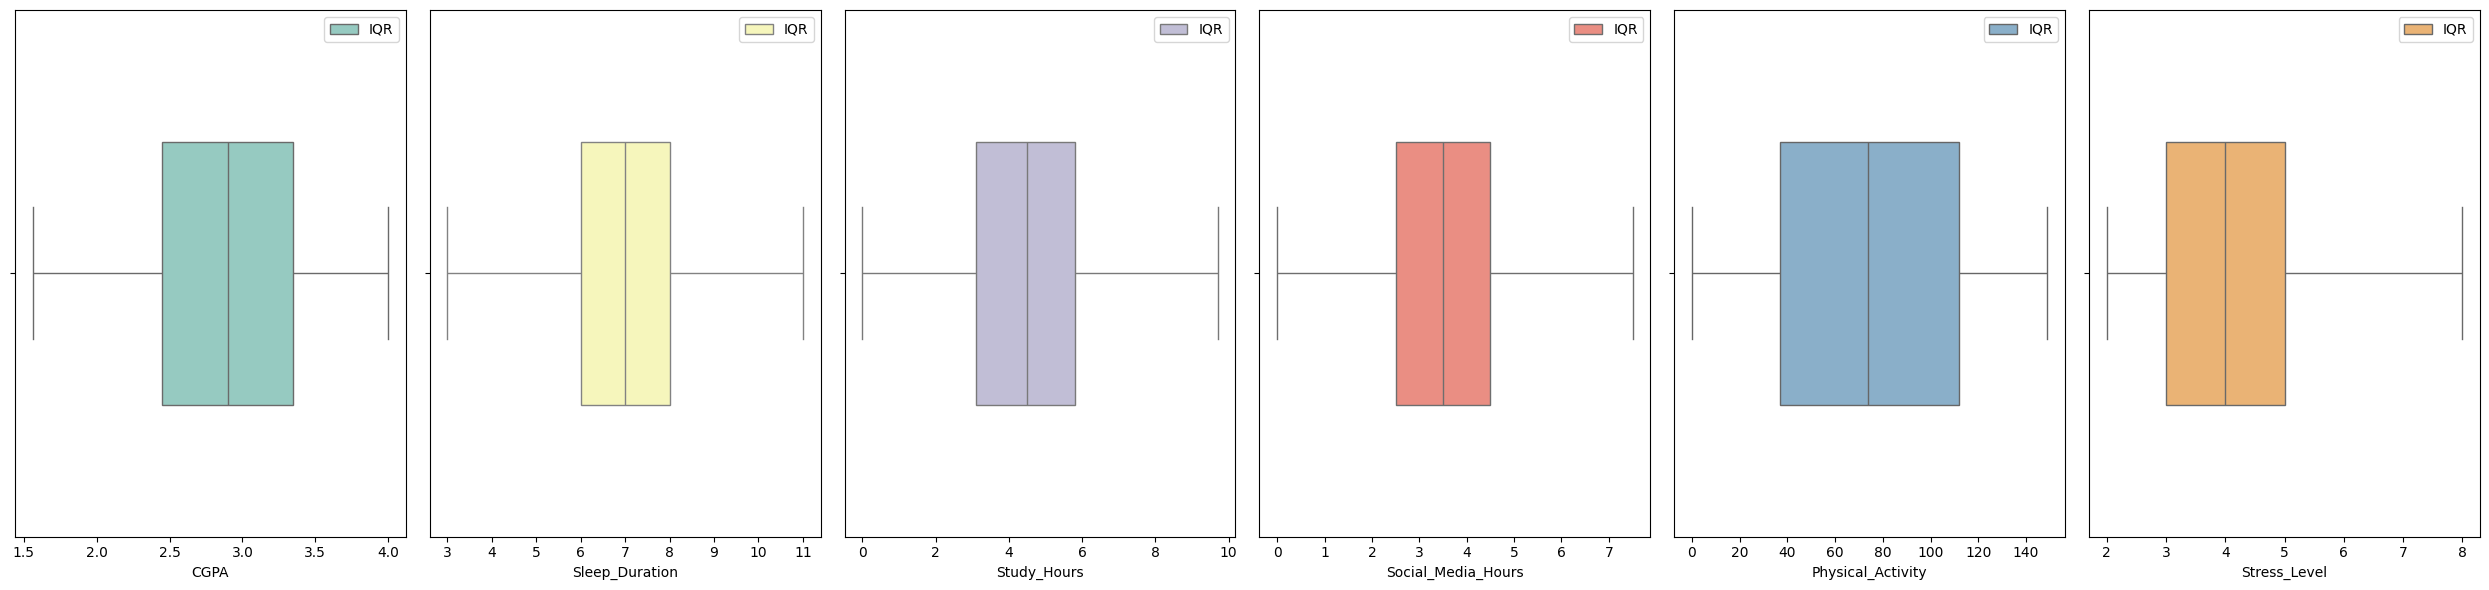

In [ ]:
number_columns = df.select_dtypes(include="number").columns.drop("Depression").tolist()
fig, axes = plt.subplots(1, len(number_columns), figsize=(25, 6))

color_palette = sns.color_palette("Set3", len(number_columns))

for cur_index, column in enumerate(number_columns):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  mask = ~((df[column] < lower_bound) | (df[column] > upper_bound))

  df = df[mask]

  sns.boxplot(data=df, x=column, ax=axes[cur_index], color=color_palette[cur_index], width=0.5)

  axes[cur_index].set_title = f"{column}"

  axes[cur_index].legend(["IQR"], loc='best')

plt.tight_layout()
plt.show()

## Feature Engineering

### Добавление новых признаков

Будут добавлены следующие признаки
- Study_Intensity - показывает соотношение времени обучения ко времени в соц. сетях. Формула: `Study_Hours / Social_Media_Hours`
- Health_Index - индекс здоровья. Формула: `Sleep_Duration * Physical_Activity`
- Rest_quality - показывает как сильно сон компенсирует общий уровень стресса. Формула: `Sleep_Duration / Stress_Level`

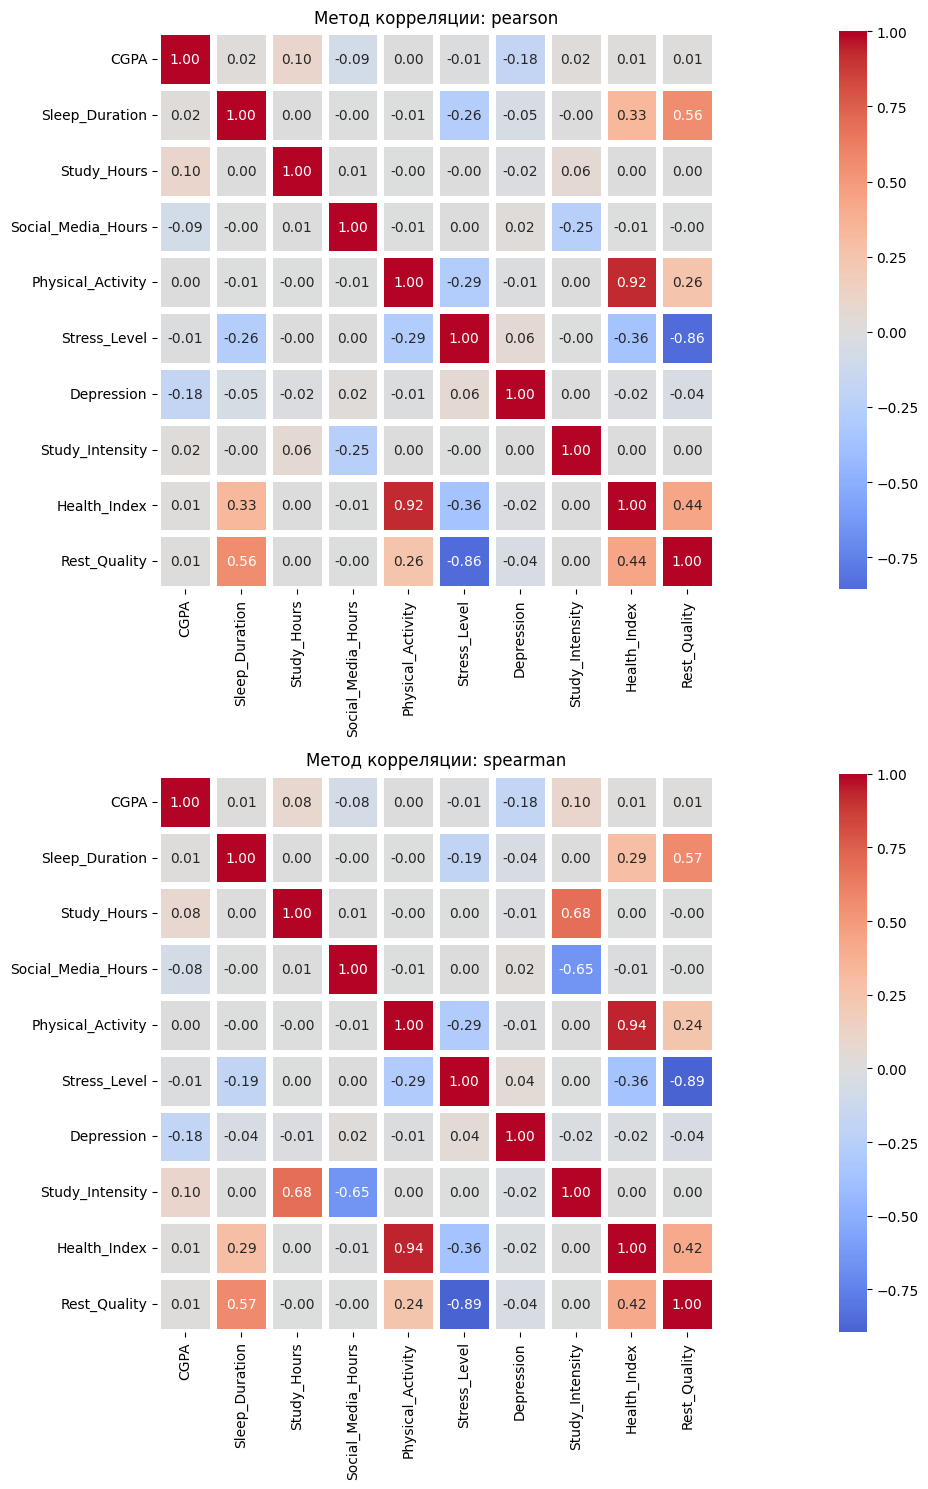

In [ ]:
df['Study_Intensity'] = (df['Study_Hours'] / (df['Social_Media_Hours'] + 0.01)) / 100
df['Health_Index'] = df['Sleep_Duration'] * df['Physical_Activity']
df['Rest_Quality'] = df['Sleep_Duration'] / (df['Stress_Level'] + 0.01)

feat_eng_columns = ['Study_Intensity', 'Health_Index', 'Rest_Quality']

fig, axes = plt.subplots(2, 1, figsize=(25, 15))

for i, cur_method in enumerate(['pearson', 'spearman']):
  corr = df.corr(method=cur_method)
  sns.heatmap(
      data=corr,
      annot=True,
      linewidths=5,
      center=0,
      square=True,
      fmt='.2f',
      cmap='coolwarm',
      ax=axes[i]

  )
  axes[i].set_title(f"Метод корреляции: {cur_method}")
plt.tight_layout()
plt.show()

/tmp/ipykernel_11094/3205394814.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='best')
/tmp/ipykernel_11094/3205394814.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='best')
/tmp/ipykernel_11094/3205394814.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='best')


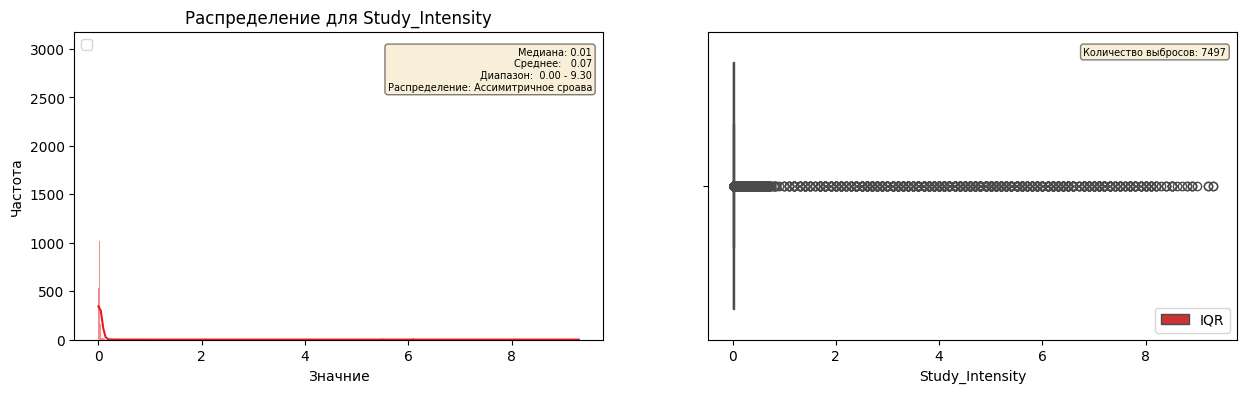

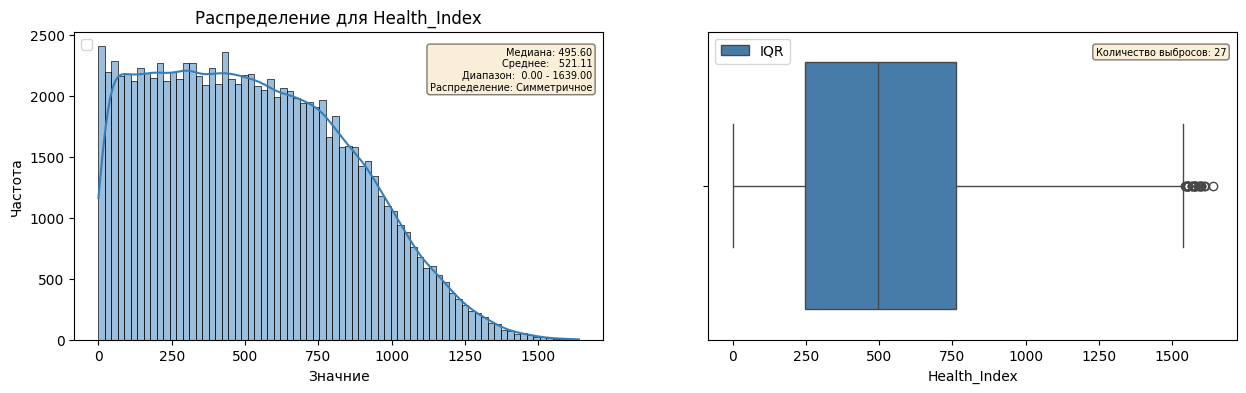

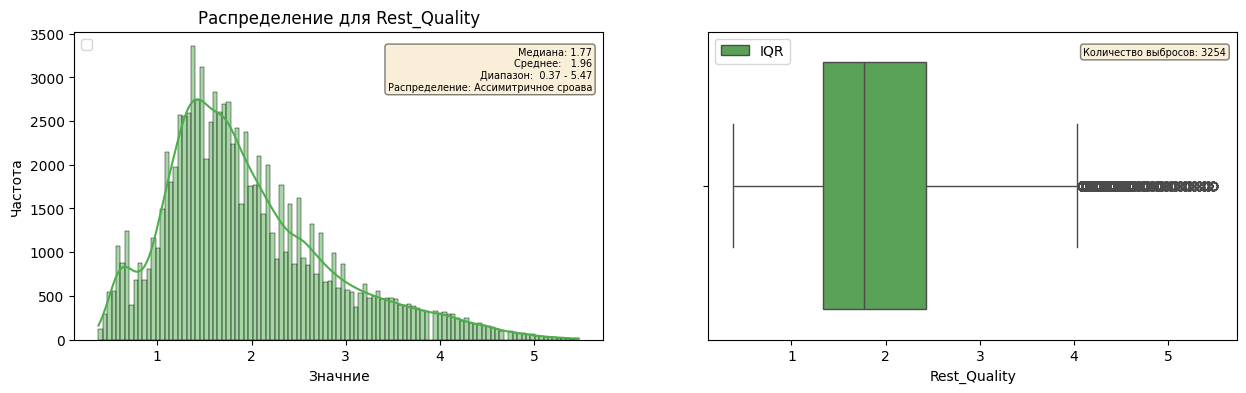

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

color_palette_1 = sns.color_palette("Set1", len(feat_eng_columns))
color_palette_2 = sns.color_palette("Set1", len(feat_eng_columns))

for index, column_name in enumerate(feat_eng_columns):
  column = df[column_name]
  fig, axes = plt.subplots(1, 2, figsize=(15, 4))

  sns.histplot(data=df, x=column, color = color_palette_1[index], ax=axes[0], kde=True)
  axes[0].set_title(f"Распределение для {column_name}")
  axes[0].set_xlabel("Значние")
  axes[0].set_ylabel("Частота")

  skew = column.skew()

  if abs(skew) < 0.5:
    skew_text = "Симметричное"
  elif skew > 0:
    skew_text = "Ассимитричное сроава"
  else:
    skew_text = "Ассимитричное слева"

  stats_text = (f"Медиана: {column.median():.2f}\n"
  f"Среднее:   {column.mean():.2f}\n"
  f"Диапазон:  {column.min():.2f} - {column.max():.2f}\n"
  f"Распределение: {skew_text}"
  )

  axes[0].text(0.98, 0.95, stats_text, transform=axes[0].transAxes,
              fontsize=7, verticalalignment='top', horizontalalignment='right',
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
  axes[0].legend(loc='best')

  sns.boxplot(data=df, x=column, ax=axes[1], color=color_palette_2[index])
  axes[1].legend(["IQR"], loc='best')

  Q1 = column.quantile(0.25)
  Q3 = column.quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers_count = ((column < lower_bound) | (column > upper_bound)).sum()
  outliers_text = (f"Количество выбросов: {outliers_count}")

  axes[1].text(0.98, 0.95, outliers_text, transform=axes[1].transAxes,
               fontsize=7, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()


- Огромное количество "выбрсоов" в Study_Intensity обусловлено математикой форумулы получения признака. Если удалить выбросы, мы удалим самых продуктивных учеников, что может отразиться на предсказании CGRP
- В Health_Index количество выбросов крайне мало, их удаление не повлияет, а если и повлияет, то крайне незначитально, на предсказания модели. Здесь выбросы - самые "здоровые" студенты
- В Rest_Quality количество выбросов также обусловлено математикой формулы. Признак, который образуется перемножением двух других, всегда будет иметь длинный хвост. Здесь выбросы - хорошо отдохнувшие студенты. Если их удалить, модель будет видеть только студентов с маленьким коэффициентом одыха, т.е. тех, которые меньше спят и у которых большой уровень стресса

## Масштабирование и обучение линейной регрессии

Metrics Train | MSE: 0.2773 | MAE: 0.4537 | RMSE: 0.5266 | R2: 0.0170
Metrics Validation | MSE: 0.2808 | MAE: 0.4568 | RMSE: 0.5299 | R2: 0.0159
Metrics Test | MSE: 0.2791 | MAE: 0.4552 | RMSE: 0.5283 | R2: 0.0141


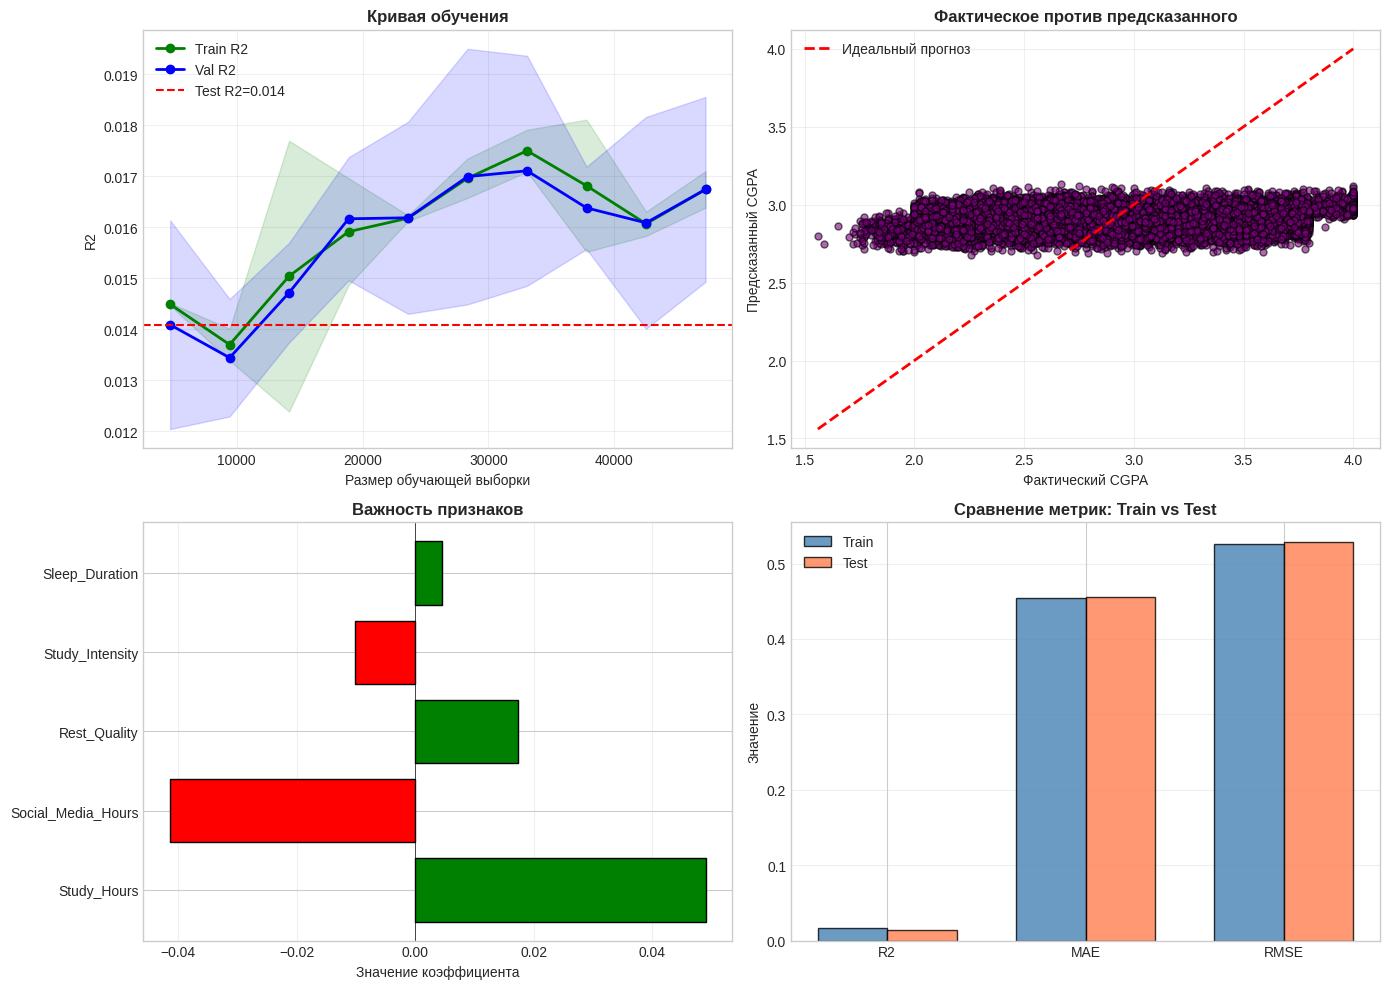

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Study_Intensity', 'Rest_Quality']

X = df[features]
y = df['CGPA']
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = SGDRegressor(max_iter=1500, eta0=0.01, random_state=42)
model.fit(X_train_scaled, y_train)

def evaluate(m, X, y, label):
    pred = m.predict(X)
    mse = mean_squared_error(y, pred)
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, pred)
    print(f"Metrics {label} | MSE: {mse:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

train_metrics = evaluate(model, X_train_scaled, y_train, "Train")
val_metrics = evaluate(model, X_val_scaled, y_val, "Validation")
test_metrics = evaluate(model, X_test_scaled, y_test, "Test")

y_test_pred = model.predict(X_test_scaled)

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2', n_jobs=-1
)

axes[0, 0].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='green', label='Train R2', linewidth=2)
axes[0, 0].fill_between(train_sizes, np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                        np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.15, color='green')
axes[0, 0].plot(train_sizes, np.mean(val_scores, axis=1), 'o-', color='blue', label='Val R2', linewidth=2)
axes[0, 0].fill_between(train_sizes, np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
                        np.mean(val_scores, axis=1) + np.std(val_scores, axis=1), alpha=0.15, color='blue')
axes[0, 0].set_xlabel('Размер обучающей выборки', fontsize=10)
axes[0, 0].set_ylabel('R2', fontsize=10)
axes[0, 0].set_title('Кривая обучения', fontsize=12, fontweight='bold')
axes[0, 0].axhline(y=test_metrics['R2'], color='red', linestyle='--', lw=1.5, label=f'Test R2={test_metrics["R2"]:.3f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='black', s=25, color='purple')
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеальный прогноз')
axes[0, 1].set_xlabel('Фактический CGPA', fontsize=10)
axes[0, 1].set_ylabel('Предсказанный CGPA', fontsize=10)
axes[0, 1].set_title('Фактическое против предсказанного', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

coef_df = pd.DataFrame({'feature': X.columns, 'coef': model.coef_})
coef_df = coef_df.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False)

colors = ['green' if c > 0 else 'red' for c in coef_df['coef']]
axes[1, 0].barh(coef_df['feature'], coef_df['coef'], color=colors, edgecolor='black')
axes[1, 0].set_xlabel('Значение коэффициента', fontsize=10)
axes[1, 0].set_title('Важность признаков', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')
axes[1, 0].axvline(x=0, color='black', lw=0.5)

metrics_names = ['R2', 'MAE', 'RMSE']
x_pos = np.arange(len(metrics_names))
width = 0.35
train_vals = [train_metrics['R2'], train_metrics['MAE'], train_metrics['RMSE']]
test_vals = [test_metrics['R2'], test_metrics['MAE'], test_metrics['RMSE']]

axes[1, 1].bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
axes[1, 1].bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(metrics_names)
axes[1, 1].set_ylabel('Значение', fontsize=10)
axes[1, 1].set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Вывод
Модель не переобучена. В данный момент она находится в состоянии недообучения. Модель сейчас просто угадывает, а не находит связи и предсказывает, основываясь на них. Это обосновано крайне слабыми линейными связями целевой переменной с выбранными признаками. Для нормальных результатов линейная модель просто не подходит, связей либо почти, либо они крайне тяжелые для понимания моделью

## Эксперименты

#### 1. Смена гиперпараметров

Начинаем эксперименты с гиперпараметрами
Таблица результатов экспериментов на валидационной выборке:
 learning_rate  epochs        val_r2
        0.0001     500  1.616255e-02
        0.0001    1000  1.616255e-02
        0.0001    2000  1.616255e-02
        0.0010     500  1.418484e-02
        0.0010    1000  1.418484e-02
        0.0010    2000  1.418484e-02
        0.0100     500 -3.136816e-02
        0.0100    1000 -3.136816e-02
        0.0100    2000 -3.136816e-02
        0.1000     500 -5.045224e+23
        0.1000    1000 -5.045224e+23
        0.1000    2000 -5.045224e+23

Лучшие параметры: {'learning_rate': 0.0001, 'epochs': 500} с R2: 0.0162

Metrics Train | MSE: 0.2769 | MAE: 0.4534 | RMSE: 0.5263 | R2: 0.0181
Metrics Validation | MSE: 0.2808 | MAE: 0.4568 | RMSE: 0.5299 | R2: 0.0162
Metrics Test | MSE: 0.2789 | MAE: 0.4551 | RMSE: 0.5281 | R2: 0.0147


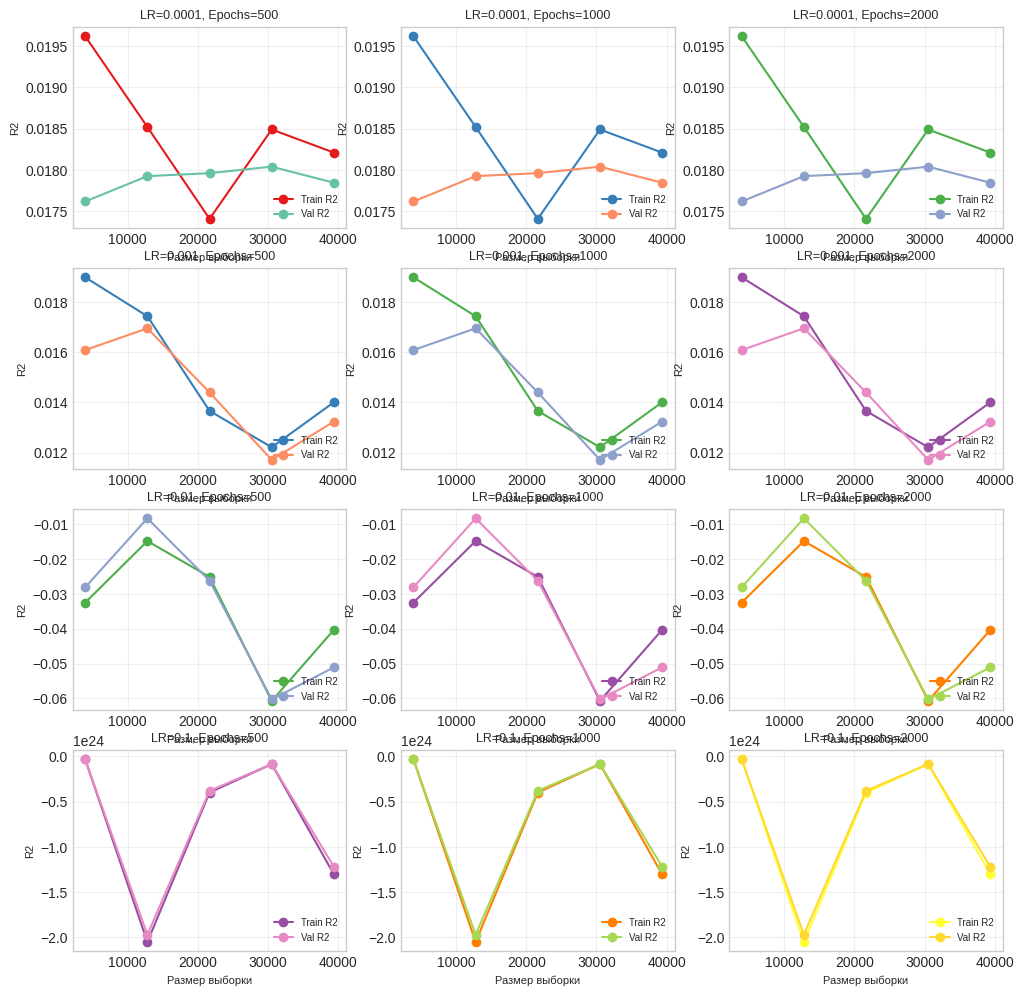

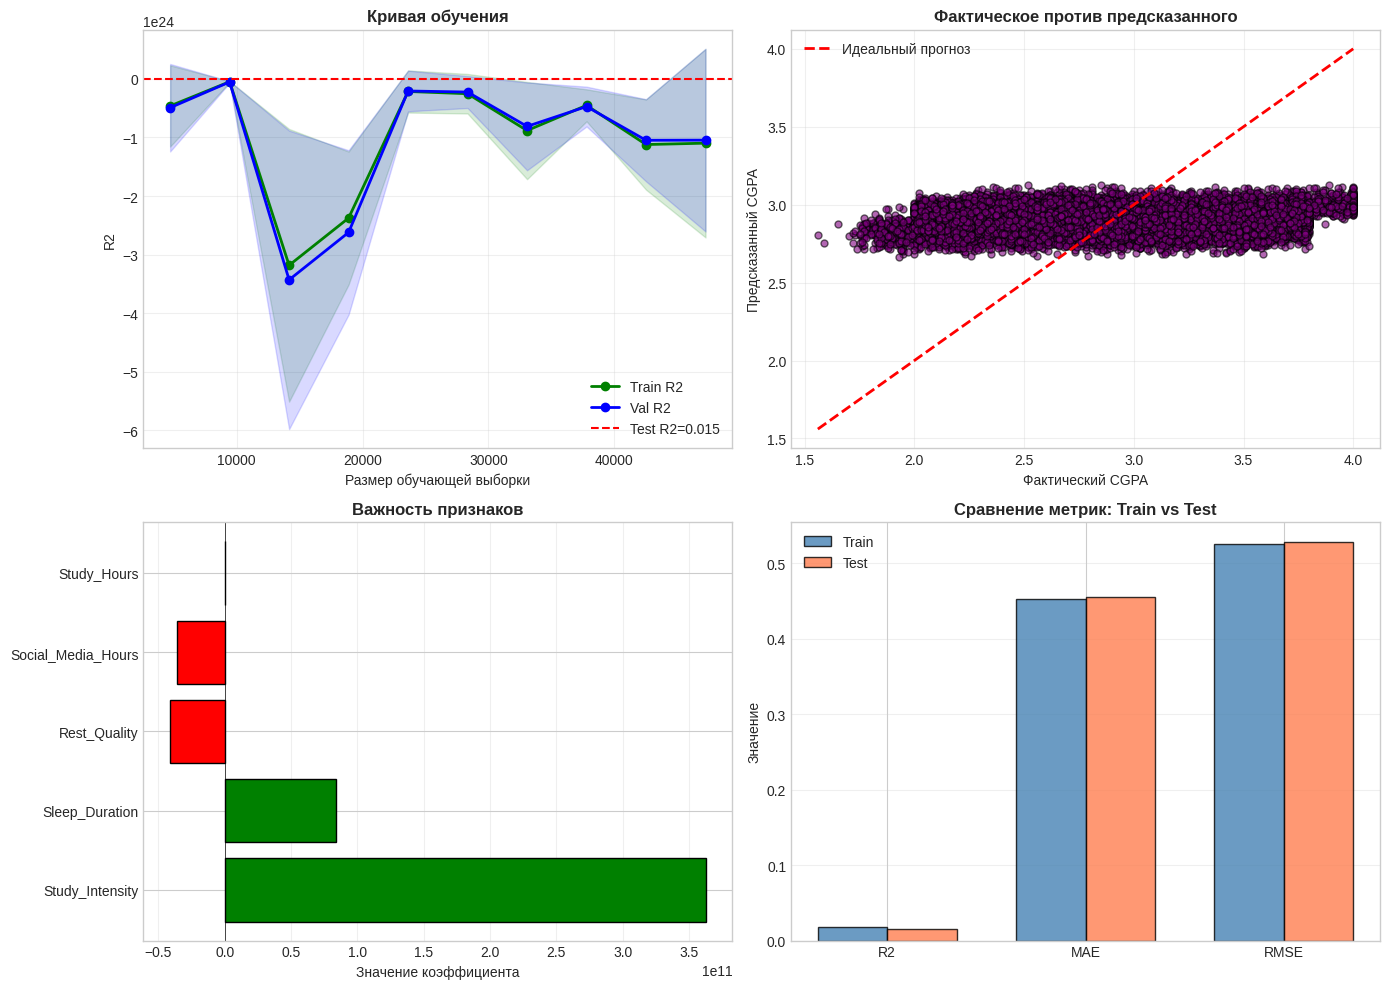

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Study_Intensity', 'Rest_Quality']

X = df[features]
y = df['CGPA']
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

learning_rates_reg = [0.0001, 0.001, 0.01, 0.1]
epochs_list_reg = [500, 1000, 2000]

best_lr_model = None
best_r2_val = -float('inf')
best_params_reg = {}
results_reg = []

color_palette_1 = sns.color_palette("Set1", len(learning_rates_reg) * len(epochs_list_reg))
color_palette_2 = sns.color_palette("Set2", len(learning_rates_reg) * len(epochs_list_reg))

print("Начинаем эксперименты с гиперпараметрами")

for lr in learning_rates_reg:
    for epochs in epochs_list_reg:
        model = SGDRegressor(
            learning_rate='constant',
            eta0=lr,
            max_iter=epochs,
            random_state=42
        )
        model.fit(X_train_scaled, y_train)

        y_val_pred = model.predict(X_val_scaled)
        val_r2 = r2_score(y_val, y_val_pred)

        results_reg.append({'learning_rate': lr, 'epochs': epochs, 'val_r2': val_r2})

        if val_r2 > best_r2_val:
            best_r2_val = val_r2
            best_lr_model = model
            best_params_reg = {'learning_rate': lr, 'epochs': epochs}

results_reg_df = pd.DataFrame(results_reg)
print("Таблица результатов экспериментов на валидационной выборке:")
print(results_reg_df.sort_values(by='val_r2', ascending=False).to_string(index=False))
print(f"\nЛучшие параметры: {best_params_reg} с R2: {best_r2_val:.4f}\n")

lr_model = best_lr_model

def evaluate(m, X, y, label):
    pred = m.predict(X)
    mse = mean_squared_error(y, pred)
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, pred)
    print(f"Metrics {label} | MSE: {mse:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

train_metrics = evaluate(lr_model, X_train_scaled, y_train, "Train")
val_metrics = evaluate(lr_model, X_val_scaled, y_val, "Validation")
test_metrics = evaluate(lr_model, X_test_scaled, y_test, "Test")

y_test_pred = lr_model.predict(X_test_scaled)

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(len(learning_rates_reg), len(epochs_list_reg), figsize=(4 * len(epochs_list_reg), 3 * len(learning_rates_reg)))

idx_row = 0
for i, lr in enumerate(learning_rates_reg):
    idx_col = 0
    for j, epochs in enumerate(epochs_list_reg):
        ax = axes[i, j] if len(learning_rates_reg) > 1 else axes[j]

        model_temp = SGDRegressor(
            learning_rate='constant',
            eta0=lr,
            max_iter=epochs,
            tol=1e-3,
            random_state=42
        )

        train_sizes, train_scores, val_scores = learning_curve(
            model_temp, X_train_scaled, y_train, cv=3,
            train_sizes=np.linspace(0.1, 1.0, 5), scoring='r2', n_jobs=-1
        )

        train_mean = np.mean(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)

        ax.plot(train_sizes, train_mean, 'o-', color=color_palette_1[i + j], label='Train R2', linewidth=1.5)
        ax.plot(train_sizes, val_mean, 'o-', color=color_palette_2[i + j], label='Val R2', linewidth=1.5)
        ax.set_title(f'LR={lr}, Epochs={epochs}', fontsize=9)
        ax.set_xlabel('Размер выборки', fontsize=8)
        ax.set_ylabel('R2', fontsize=8)
        ax.legend(loc='lower right', fontsize=7)
        ax.grid(True, alpha=0.3)

        idx_col += 1
    idx_row += 1

plt.tight_layout()
plt.show()

### Результат эксперимента
- Подобраны оптимальные гиперпараметры для обучения: 'learning_rate': 0.0001, 'epochs': 500
- Если сравнивать с результатом без подбора гиперпараметров, то модель стала совсем немного лучше по метрикам, но на общей ситуации это не сказалось

#### 2. Не удалять выбросы при анализе датасета

Metrics Train | MSE: 0.2780 | MAE: 0.4542 | RMSE: 0.5272 | R2: 0.0186
Metrics Validation | MSE: 0.2778 | MAE: 0.4545 | RMSE: 0.5271 | R2: 0.0184
Metrics Test | MSE: 0.2791 | MAE: 0.4554 | RMSE: 0.5283 | R2: 0.0161


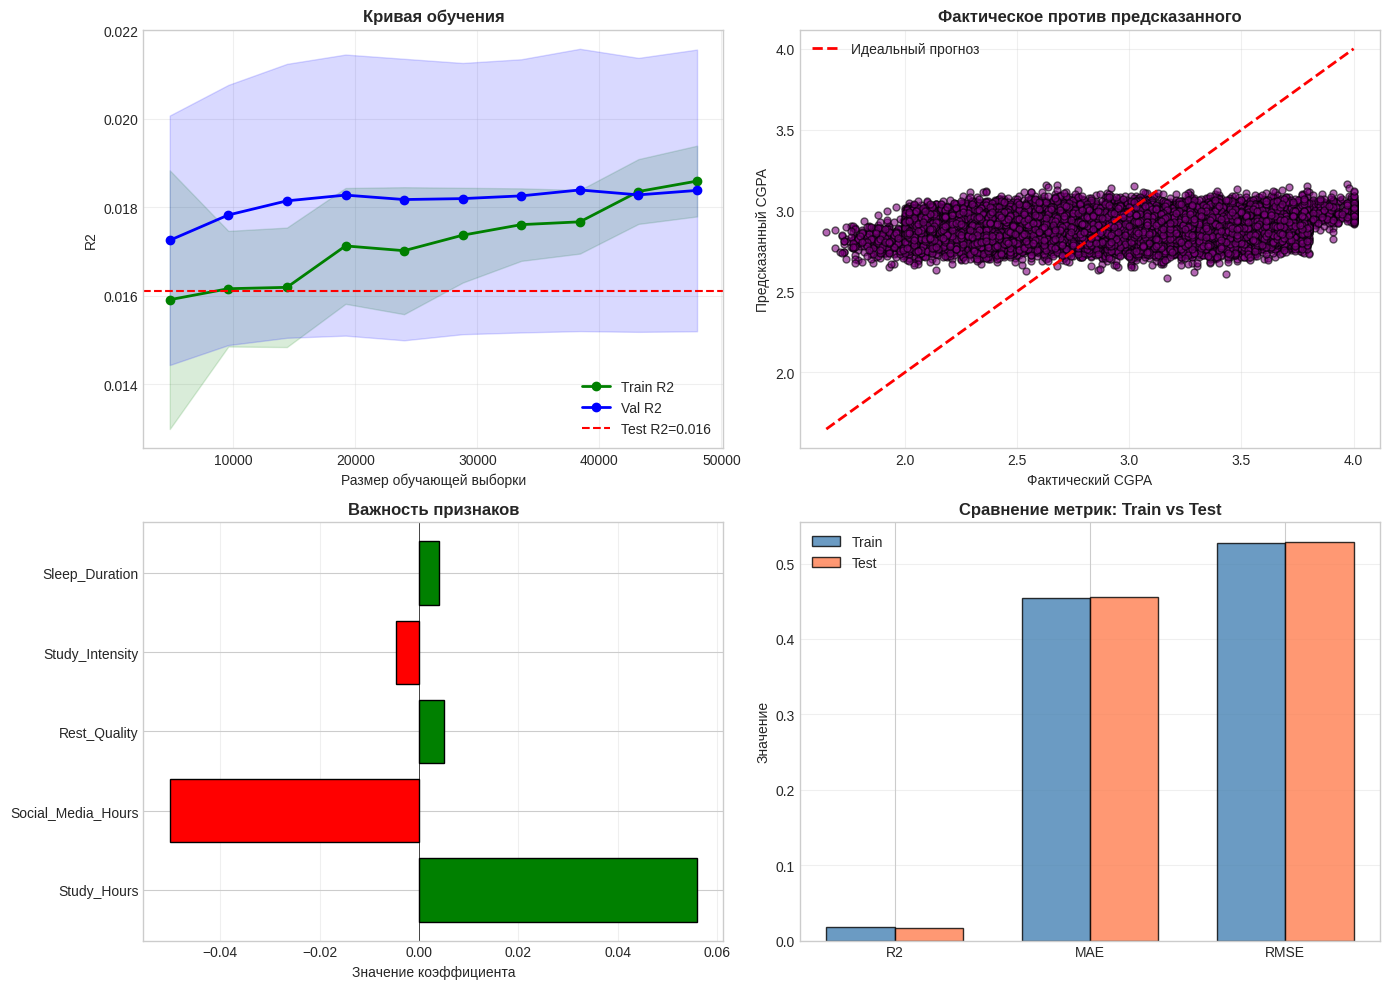

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



df_dirt = pd.read_csv("/content/drive/MyDrive/student_lifestyle_100k.csv")
df_dirt.drop(columns=['Age', 'Gender', 'Department'], inplace=True)
df_dirt['Study_Intensity'] = df_dirt['Study_Hours'] / (df_dirt['Social_Media_Hours'] + 0.01)
df_dirt['Health_Index'] = df_dirt['Sleep_Duration'] * df_dirt['Physical_Activity']
df_dirt['Rest_Quality'] = df_dirt['Sleep_Duration'] / (df_dirt['Stress_Level'] + 0.01)

features = ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Study_Intensity', 'Rest_Quality']

X = df_dirt[features]
y = df_dirt['CGPA']
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = SGDRegressor(max_iter=500, eta0=0.001, random_state=42)
model.fit(X_train_scaled, y_train)

def evaluate(m, X, y, label):
    pred = m.predict(X)
    mse = mean_squared_error(y, pred)
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, pred)
    print(f"Metrics {label} | MSE: {mse:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

train_metrics = evaluate(model, X_train_scaled, y_train, "Train")
val_metrics = evaluate(model, X_val_scaled, y_val, "Validation")
test_metrics = evaluate(model, X_test_scaled, y_test, "Test")

y_test_pred = model.predict(X_test_scaled)

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2', n_jobs=-1
)

axes[0, 0].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='green', label='Train R2', linewidth=2)
axes[0, 0].fill_between(train_sizes, np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                        np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.15, color='green')
axes[0, 0].plot(train_sizes, np.mean(val_scores, axis=1), 'o-', color='blue', label='Val R2', linewidth=2)
axes[0, 0].fill_between(train_sizes, np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
                        np.mean(val_scores, axis=1) + np.std(val_scores, axis=1), alpha=0.15, color='blue')
axes[0, 0].set_xlabel('Размер обучающей выборки', fontsize=10)
axes[0, 0].set_ylabel('R2', fontsize=10)
axes[0, 0].set_title('Кривая обучения', fontsize=12, fontweight='bold')
axes[0, 0].axhline(y=test_metrics['R2'], color='red', linestyle='--', lw=1.5, label=f'Test R2={test_metrics["R2"]:.3f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='black', s=25, color='purple')
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеальный прогноз')
axes[0, 1].set_xlabel('Фактический CGPA', fontsize=10)
axes[0, 1].set_ylabel('Предсказанный CGPA', fontsize=10)
axes[0, 1].set_title('Фактическое против предсказанного', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

coef_df_dirt = pd.DataFrame({'feature': X.columns, 'coef': model.coef_})
coef_df_dirt = coef_df_dirt.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False)

colors = ['green' if c > 0 else 'red' for c in coef_df_dirt['coef']]
axes[1, 0].barh(coef_df_dirt['feature'], coef_df_dirt['coef'], color=colors, edgecolor='black')
axes[1, 0].set_xlabel('Значение коэффициента', fontsize=10)
axes[1, 0].set_title('Важность признаков', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')
axes[1, 0].axvline(x=0, color='black', lw=0.5)

metrics_names = ['R2', 'MAE', 'RMSE']
x_pos = np.arange(len(metrics_names))
width = 0.35
train_vals = [train_metrics['R2'], train_metrics['MAE'], train_metrics['RMSE']]
test_vals = [test_metrics['R2'], test_metrics['MAE'], test_metrics['RMSE']]

axes[1, 1].bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
axes[1, 1].bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(metrics_names)
axes[1, 1].set_ylabel('Значение', fontsize=10)
axes[1, 1].set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Результаты эксперимента
- Метрики поменялись незначительно. Модель все так же плохо спарвляется с предсказаниями
- MAE и RMSE стали выше, при этом дисперсия тоже повысилась

## Масштабирование и обучение логистической регрессии

              precision    recall  f1-score   support

           0       0.94      0.67      0.78     17729
           1       0.17      0.61      0.26      1953

    accuracy                           0.66     19682
   macro avg       0.55      0.64      0.52     19682
weighted avg       0.86      0.66      0.73     19682



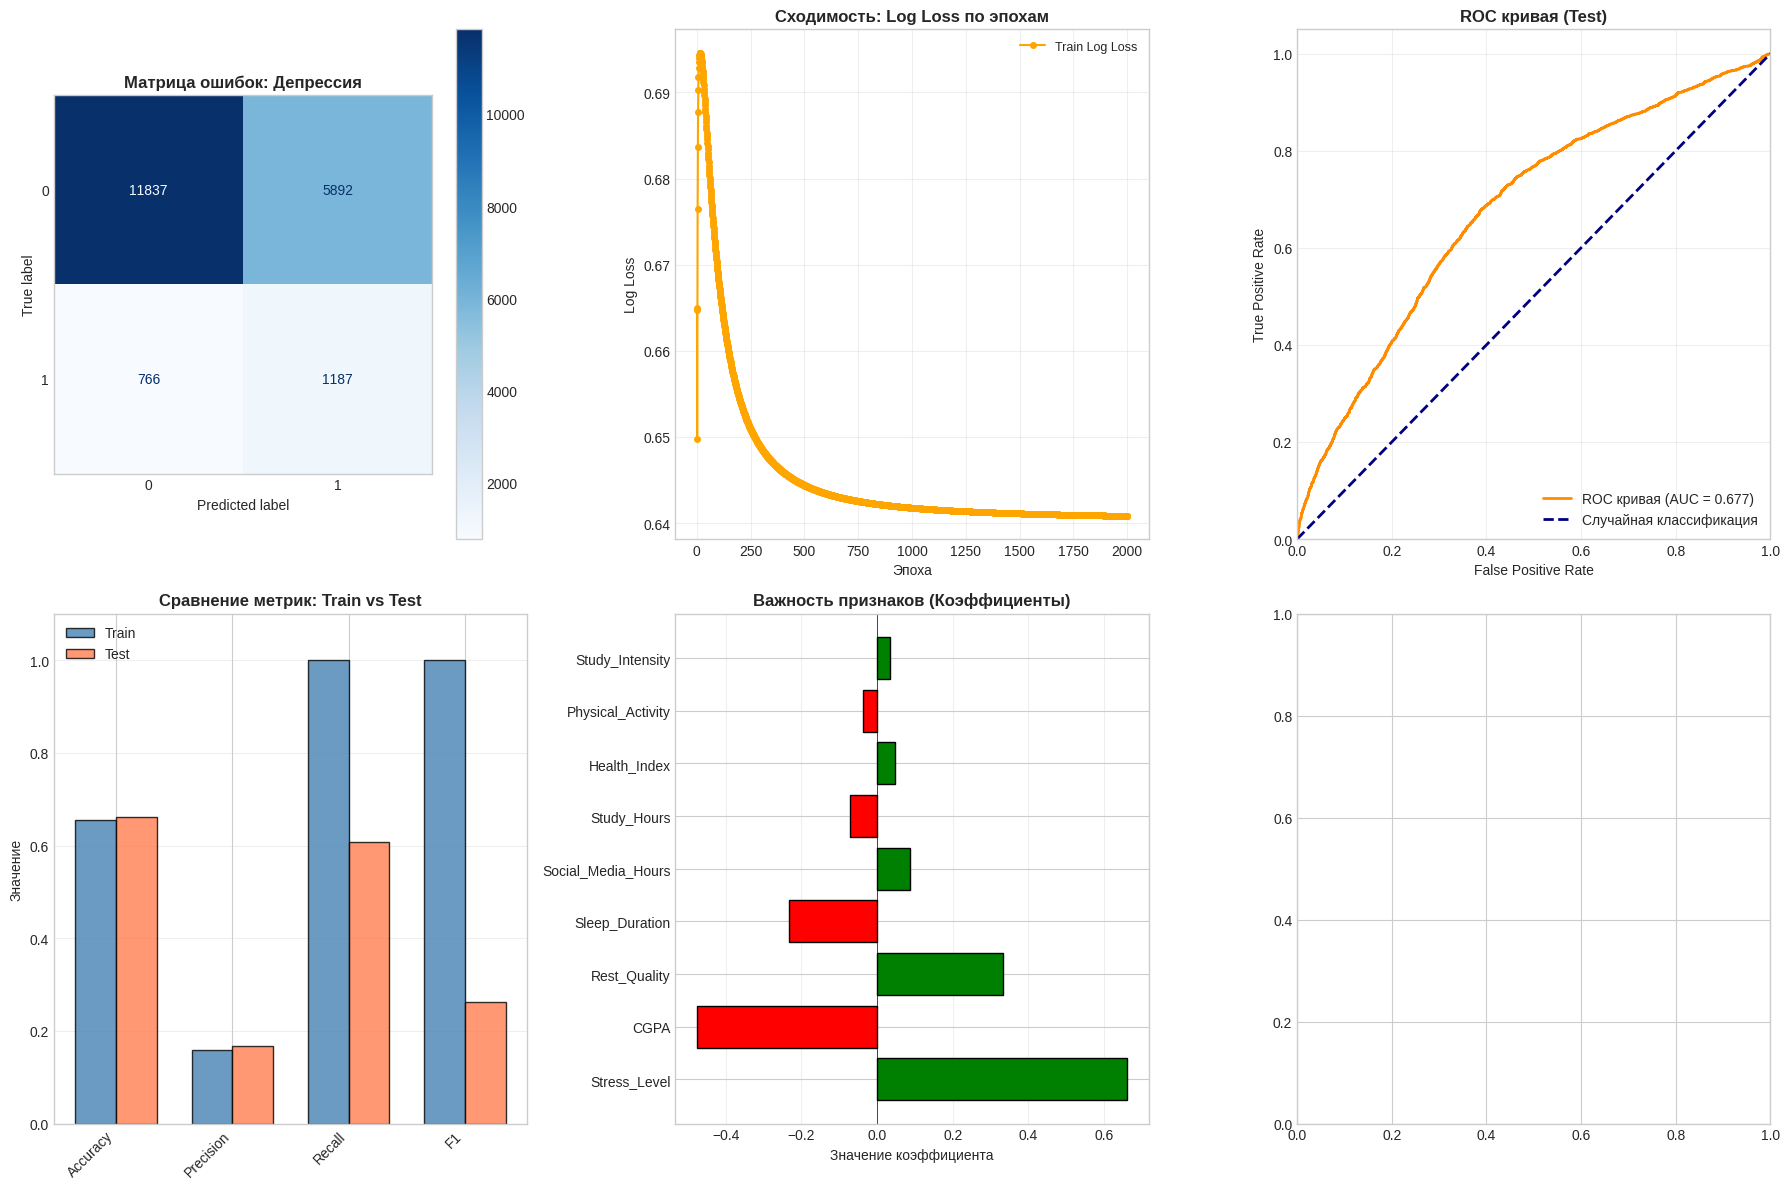

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt

X_clf = df.drop(columns=['Depression'])
y_clf = df['Depression']

X_train_val_c, X_test_c, y_train_val_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_train_val_c, y_train_val_c, test_size=0.25, random_state=42, stratify=y_train_val_c
)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_val_c_scaled = scaler_c.transform(X_val_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

classes = np.unique(y_train_c)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_c)
class_weight_dict = dict(zip(classes, class_weights))

clf_model = SGDClassifier(loss='log_loss', max_iter=2000, tol=1e-3, random_state=42, class_weight=class_weight_dict)
clf_model.fit(X_train_c_scaled, y_train_c)

y_pred_train = clf_model.predict(X_train_c_scaled)
y_pred_test = clf_model.predict(X_test_c_scaled)
y_test_proba = clf_model.predict_proba(X_test_c_scaled)[:, 1]

print(classification_report(y_test_c, y_pred_test))

auc_roc = roc_auc_score(y_test_c, y_test_proba)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
train_vals = [
    accuracy_score(y_train_c, y_pred_train),
    precision_score(y_train_c, y_pred_train),
    recall_score(y_train_c, y_train_c),
    f1_score(y_train_c, y_train_c)
]
test_vals = [
    accuracy_score(y_test_c, y_pred_test),
    precision_score(y_test_c, y_pred_test),
    recall_score(y_test_c, y_pred_test),
    f1_score(y_test_c, y_pred_test)
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_test, ax=axes[0, 0], cmap='Blues')
axes[0, 0].grid(False)
axes[0, 0].set_title('Матрица ошибок: Депрессия', fontsize=12, fontweight='bold')

lgr_model = SGDClassifier(loss='log_loss', max_iter=1, warm_start=True, random_state=42, class_weight=class_weight_dict)
n_epochs = 2000
train_losses = []

for epoch in range(n_epochs):
    lgr_model.partial_fit(X_train_c_scaled, y_train_c, classes=classes)
    y_pred_proba = lgr_model.predict_proba(X_train_c_scaled)
    loss = -np.mean(y_train_c * np.log(y_pred_proba[:, 1] + 1e-15) +
                    (1 - y_train_c) * np.log(y_pred_proba[:, 0] + 1e-15))
    train_losses.append(loss)

axes[0, 1].plot(range(1, n_epochs + 1), train_losses, 'o-', color='orange',
             label='Train Log Loss', markersize=4, linewidth=1.5)
axes[0, 1].set_xlabel('Эпоха', fontsize=10)
axes[0, 1].set_ylabel('Log Loss', fontsize=10)
axes[0, 1].set_title('Сходимость: Log Loss по эпохам', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='upper right', fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

fpr, tpr, thresholds = roc_curve(y_test_c, y_test_proba)
axes[0, 2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC кривая (AUC = {auc_roc:.3f})')
axes[0, 2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайная классификация')
axes[0, 2].set_xlim([0.0, 1.0])
axes[0, 2].set_ylim([0.0, 1.05])
axes[0, 2].set_xlabel('False Positive Rate', fontsize=10)
axes[0, 2].set_ylabel('True Positive Rate', fontsize=10)
axes[0, 2].set_title('ROC кривая (Test)', fontsize=12, fontweight='bold')
axes[0, 2].legend(loc="lower right")
axes[0, 2].grid(True, alpha=0.3)

x_pos = np.arange(len(metrics_names))
width = 0.35
axes[1, 0].bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
axes[1, 0].bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(metrics_names, rotation=45, ha='right')
axes[1, 0].set_ylabel('Значение', fontsize=10)
axes[1, 0].set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_ylim([0, 1.1])

feature_names = X_clf.columns
coefficients = clf_model.coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefficients})
coef_df = coef_df.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False)

colors = ['green' if c > 0 else 'red' for c in coef_df['coef']]
axes[1, 1].barh(coef_df['feature'], coef_df['coef'], color=colors, edgecolor='black')
axes[1, 1].set_xlabel('Значение коэффициента', fontsize=10)
axes[1, 1].set_title('Важность признаков (Коэффициенты)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')
axes[1, 1].axvline(x=0, color='black', lw=0.5)

plt.tight_layout()
plt.show()

## Вывод
Модель показала низкую предсказательную способность. Это обусловлено особенностью датасета (признаки мало коррелируют, модели тяжело извлечь связи). Модель не переобучена, что видно на сравнении метрик Train и Test. Из метрик и матрицы ошибок можно сделать вывод, что модель склонна к "ложным диагнозам" депрессии (recall для 0 = 0.67). Также такие слабые показатели могут быть обусловленны сильным дисбалансом классов

## Эксперименты

### 1. Эксперименты с гиперпараметрами

Начинаем эксперименты с гиперпараметрами...

Таблица результатов экспериментов на валидационной выборке:
 learning_rate  epochs   val_f1
        0.0001     500 0.266771
        0.0001    1000 0.266771
        0.0001    2000 0.266771
        0.0100    1000 0.259878
        0.0100    2000 0.259878
        0.0100     500 0.259878
        0.0010     500 0.258713
        0.0010    2000 0.258713
        0.0010    1000 0.258713
        0.1000     500 0.209040
        0.1000    1000 0.209040
        0.1000    2000 0.209040
Лучшие метрики: learning_rate: 0.0001, epochs: 500
              precision    recall  f1-score   support

           0       0.95      0.62      0.75     17729
           1       0.17      0.70      0.27      1953

    accuracy                           0.63     19682
   macro avg       0.56      0.66      0.51     19682
weighted avg       0.87      0.63      0.70     19682



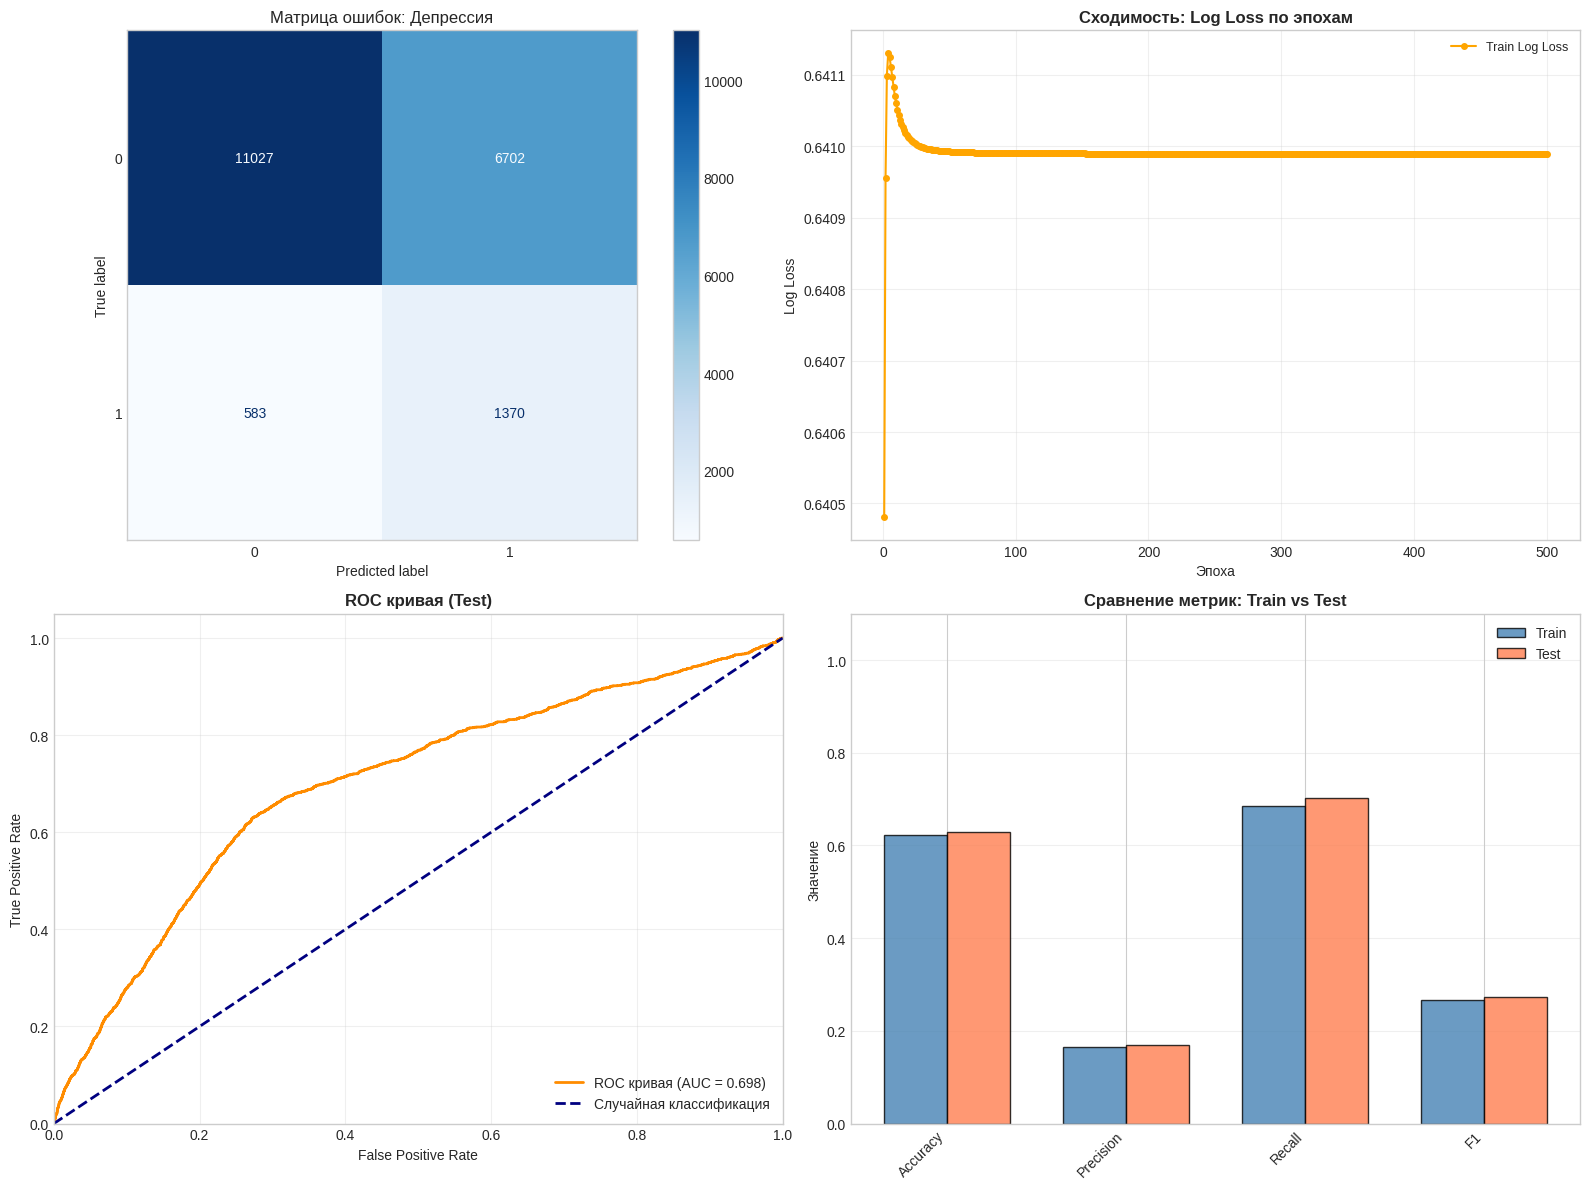

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

learning_rates = [0.0001, 0.001, 0.01, 0.1]
epochs_list = [500, 1000, 2000]

best_model = None
best_f1 = 0
best_params = {}
results = []

print("Начинаем эксперименты с гиперпараметрами...\n")

for lr in learning_rates:
    for epochs in epochs_list:
        model = SGDClassifier(
            loss='log_loss',
            learning_rate='constant',
            eta0=lr,
            max_iter=epochs,
            tol=1e-3,
            random_state=42,
            class_weight='balanced'
        )
        model.fit(X_train_c_scaled, y_train_c)

        y_val_pred = model.predict(X_val_c_scaled)
        val_f1 = f1_score(y_val_c, y_val_pred)

        results.append({'learning_rate': lr, 'epochs': epochs, 'val_f1': val_f1})

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model = model
            best_params = {'learning_rate': lr, 'epochs': epochs}

results_df = pd.DataFrame(results)
print("Таблица результатов экспериментов на валидационной выборке:")
print(results_df.sort_values(by='val_f1', ascending=False).to_string(index=False))
print(f"Лучшие метрики: learning_rate: {best_params['learning_rate']}, epochs: {best_params['epochs']}")

y_train_pred_best = best_model.predict(X_train_c_scaled)
y_test_pred_best = best_model.predict(X_test_c_scaled)

print(classification_report(y_test_c, y_test_pred_best))

auc_roc = roc_auc_score(y_test_c, best_model.predict_proba(X_test_c_scaled)[:, 1])
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
train_vals = [accuracy_score(y_train_c, y_train_pred_best), precision_score(y_train_c, y_train_pred_best),
              recall_score(y_train_c, y_train_pred_best), f1_score(y_train_c, y_train_pred_best)]
test_vals = [accuracy_score(y_test_c, y_test_pred_best), precision_score(y_test_c, y_test_pred_best),
             recall_score(y_test_c, y_test_pred_best), f1_score(y_test_c, y_test_pred_best)]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ConfusionMatrixDisplay.from_predictions(y_test_c, y_test_pred_best, ax=axes[0, 0], cmap='Blues')
axes[0, 0].grid(False)
axes[0, 0].set_title('Матрица ошибок: Депрессия')

n_epochs_plot = 500
train_losses = []

for epoch in range(n_epochs_plot):
    best_model.partial_fit(X_train_c_scaled, y_train_c, classes=np.unique(y_train_c))
    y_pred_proba = best_model.predict_proba(X_train_c_scaled)
    loss = -np.mean(y_train_c * np.log(y_pred_proba[:, 1] + 1e-15) +
                    (1 - y_train_c) * np.log(y_pred_proba[:, 0] + 1e-15))
    train_losses.append(loss)

axes[0, 1].plot(range(1, len(train_losses) + 1), train_losses, 'o-', color='orange',
             label='Train Log Loss', markersize=4, linewidth=1.5)
axes[0, 1].set_xlabel('Эпоха', fontsize=10)
axes[0, 1].set_ylabel('Log Loss', fontsize=10)
axes[0, 1].set_title('Сходимость: Log Loss по эпохам', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='upper right', fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

fpr, tpr, thresholds = roc_curve(y_test_c, best_model.predict_proba(X_test_c_scaled)[:, 1])
axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC кривая (AUC = {auc_roc:.3f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайная классификация')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate', fontsize=10)
axes[1, 0].set_ylabel('True Positive Rate', fontsize=10)
axes[1, 0].set_title('ROC кривая (Test)', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc="lower right")
axes[1, 0].grid(True, alpha=0.3)

x_pos = np.arange(len(metrics_names))
width = 0.35
axes[1, 1].bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
axes[1, 1].bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(metrics_names, rotation=45, ha='right')
axes[1, 1].set_ylabel('Значение', fontsize=10)
axes[1, 1].set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

### Результаты эксперимента:
- Получсены лучшие параметры для обучения логистической регрессии learning_rate: 0.0001, epochs: 500
- AUC почти достиг 0.7, но для заявлений, что модель хорошо раскидывает на классы, было бы неплохо достичь 0.75
- Стало больше False Positive, однако меньше False Negative и True Positive

### 2. Эксперимент с ручной балансировкой классов

Распределение классов до балансировки: [53185  5860]
Распределение классов после балансировки: [53185 53185]
              precision    recall  f1-score   support

           0       0.95      0.62      0.75     17729
           1       0.17      0.70      0.27      1953

    accuracy                           0.63     19682
   macro avg       0.56      0.66      0.51     19682
weighted avg       0.87      0.63      0.70     19682



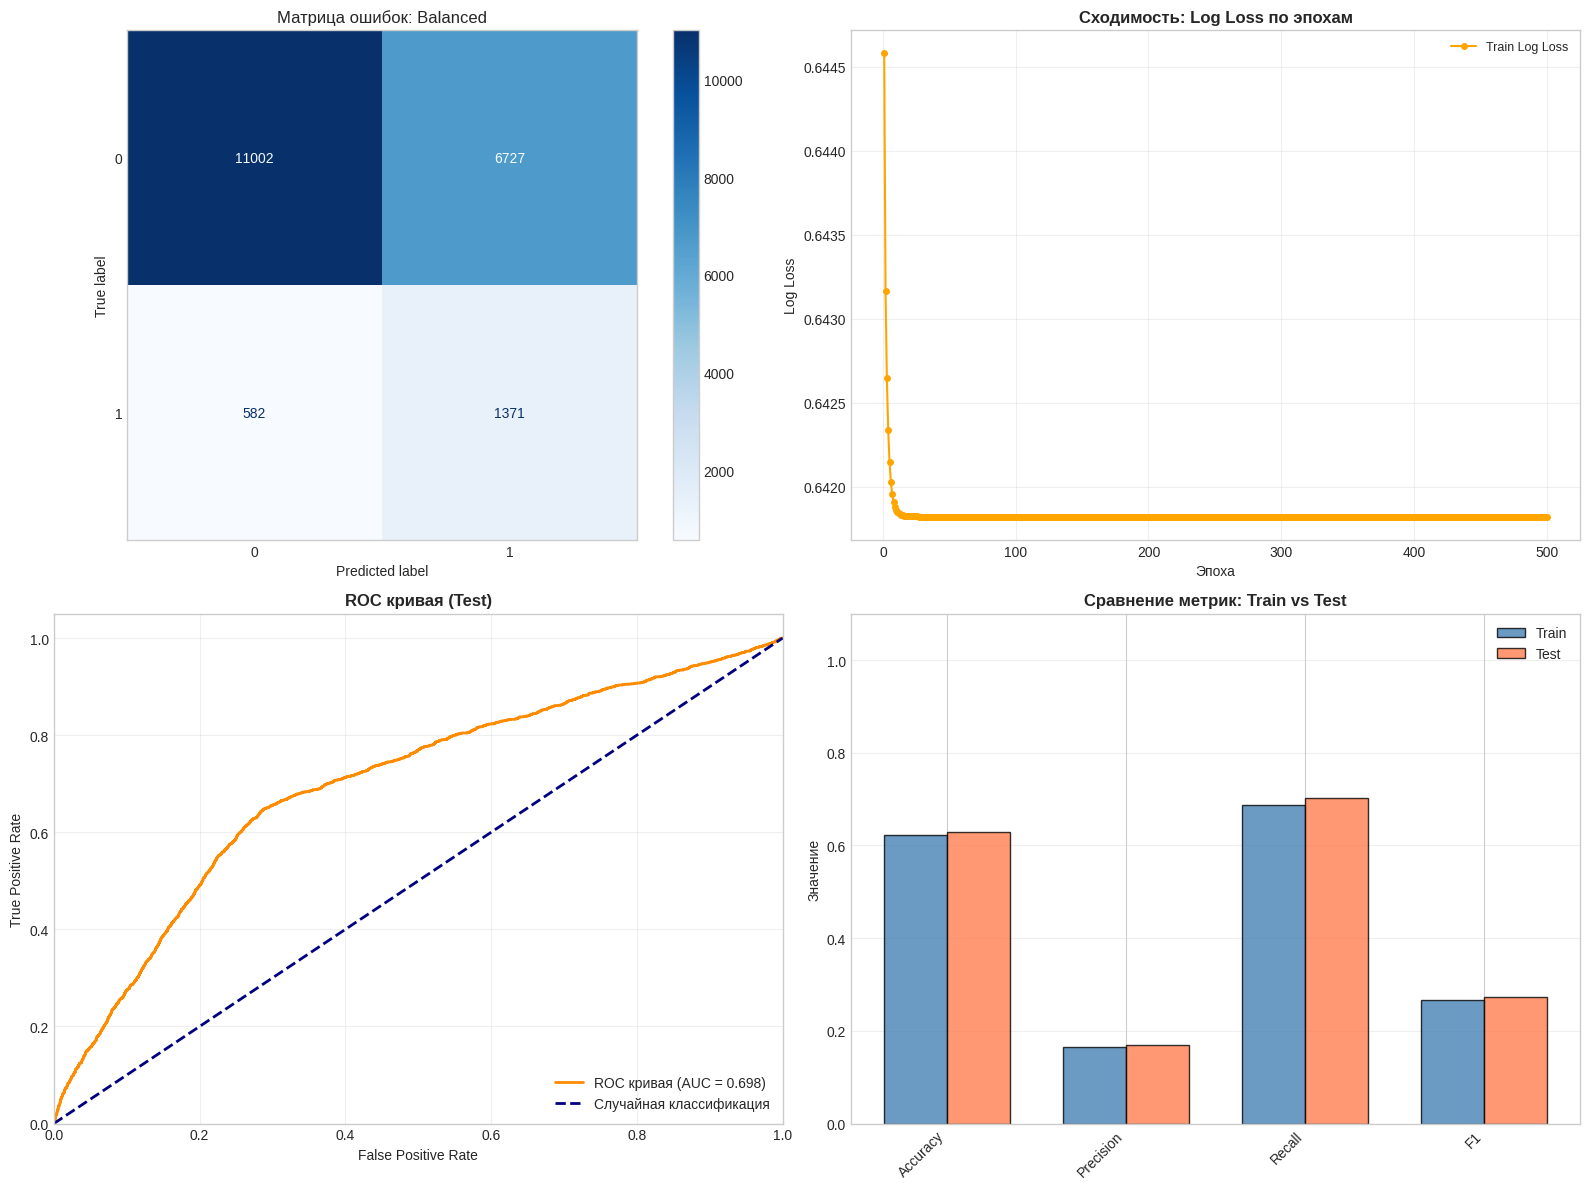

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_c_scaled, y_train_c)

print(f"Распределение классов до балансировки: {np.bincount(y_train_c)}")
print(f"Распределение классов после балансировки: {np.bincount(y_resampled)}")

balanced_model = SGDClassifier(loss='log_loss', learning_rate='constant', eta0=0.0001, max_iter=500, random_state=42, warm_start=True)
balanced_model.fit(X_resampled, y_resampled)

y_train_pred_bal = balanced_model.predict(X_train_c_scaled)
y_test_pred_bal = balanced_model.predict(X_test_c_scaled)
y_test_proba_bal = balanced_model.predict_proba(X_test_c_scaled)[:, 1]

print(classification_report(y_test_c, y_test_pred_bal))

auc_roc_bal = roc_auc_score(y_test_c, y_test_proba_bal)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
train_vals = [accuracy_score(y_train_c, y_train_pred_bal), precision_score(y_train_c, y_train_pred_bal),
              recall_score(y_train_c, y_train_pred_bal), f1_score(y_train_c, y_train_pred_bal)]
test_vals = [accuracy_score(y_test_c, y_test_pred_bal), precision_score(y_test_c, y_test_pred_bal),
             recall_score(y_test_c, y_test_pred_bal), f1_score(y_test_c, y_test_pred_bal)]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ConfusionMatrixDisplay.from_predictions(y_test_c, y_test_pred_bal, ax=axes[0, 0], cmap='Blues')
axes[0, 0].grid(False)
axes[0, 0].set_title('Матрица ошибок: Balanced')

n_epochs_plot = 500
model_conv = SGDClassifier(loss='log_loss', learning_rate='constant', eta0=0.0001, max_iter=1, random_state=42, warm_start=True)
train_losses = []

for epoch in range(n_epochs_plot):
    model_conv.partial_fit(X_resampled, y_resampled, classes=np.unique(y_resampled))
    y_pred_proba = model_conv.predict_proba(X_resampled)
    loss = -np.mean(y_resampled * np.log(y_pred_proba[:, 1] + 1e-15) +
                    (1 - y_resampled) * np.log(y_pred_proba[:, 0] + 1e-15))
    train_losses.append(loss)

axes[0, 1].plot(range(1, len(train_losses) + 1), train_losses, 'o-', color='orange',
             label='Train Log Loss', markersize=4, linewidth=1.5)
axes[0, 1].set_xlabel('Эпоха', fontsize=10)
axes[0, 1].set_ylabel('Log Loss', fontsize=10)
axes[0, 1].set_title('Сходимость: Log Loss по эпохам', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='upper right', fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

fpr, tpr, thresholds = roc_curve(y_test_c, y_test_proba_bal)
axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC кривая (AUC = {auc_roc_bal:.3f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайная классификация')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate', fontsize=10)
axes[1, 0].set_ylabel('True Positive Rate', fontsize=10)
axes[1, 0].set_title('ROC кривая (Test)', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc="lower right")
axes[1, 0].grid(True, alpha=0.3)

x_pos = np.arange(len(metrics_names))
width = 0.35
axes[1, 1].bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
axes[1, 1].bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(metrics_names, rotation=45, ha='right')
axes[1, 1].set_ylabel('Значение', fontsize=10)
axes[1, 1].set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

### Результаты эксперимента
- Метрики не поменялись вообще. Матрица почти не поменялась
- Взвешивание классов прекрасно справляется с балансировкой и выдает такой же результат, как и ручная балансировка

## Вывод

## Выводы

В ходе выполнения лабораторной работы был реализован полный цикл машинного обучения:

**Разведочный анализ данных (EDA):**
- Проведен анализ распределения признаков
- Выявлены корреляции между переменными
- Обнаружены выбросы

**Предобработка данных:**
- Проведено масштабирование признаков
- Выполнено кодирование категориальных переменных

**Feature Engineering:**
- Созданы новые признаки на основе существующих
- Проведен анализ распределения новых признаков
- Выявлены корреляции новых признаков с уже существующими

**Результаты обучения:**

Регрессия (прогнозирование CGPA):
- Лучшие метрики: MSE: 0.2791 | MAE: 0.4554 | RMSE: 0.5283 | R2: 0.0161
- Предсказания модели крайне слабые и близки к случайному предсказанию
- Наиболее важные признаки: Часы учебы (положительный), часы отдыха (отрицательный)

Классификация (депрессия):
- Достигнута точность 0.63, AUC = 0.698
- Все еще слабые показатели для того, чтобы заявить о хорошей классификации модели
- Наиболее важные признаки: уровень стресса (положительный), CGPA (отрицательный)


**Возможные улучшения:**
- Попробовать более сложные модели (Random Forest, Gradient Boosting)
- Добавить больше признаков
- Использовать кросс-валидацию для более надежной оценки